* 출처 : 밑바닥에서 시작하는 딥러닝 1


## 5.1.1 계산 그래프로 풀다

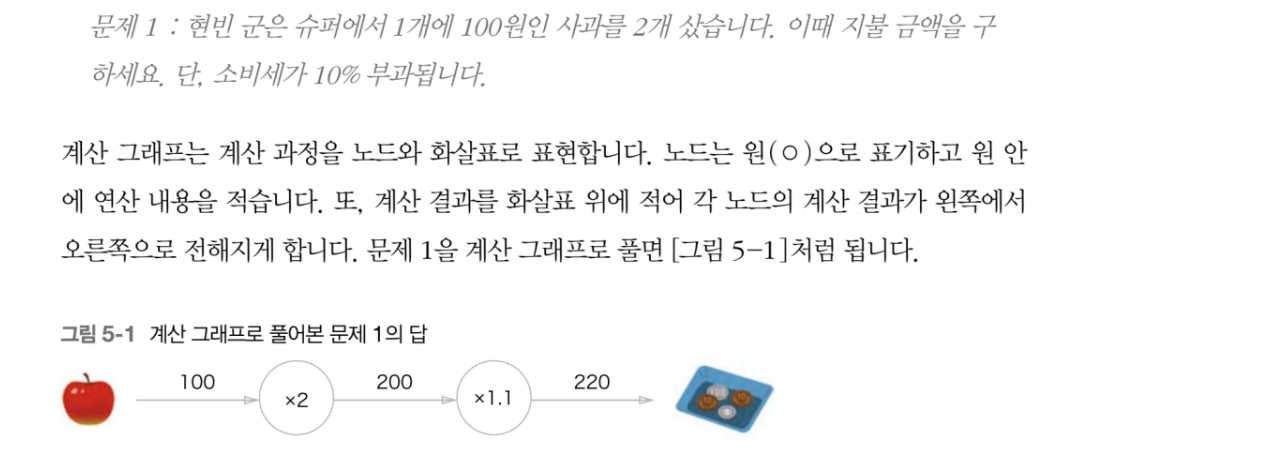

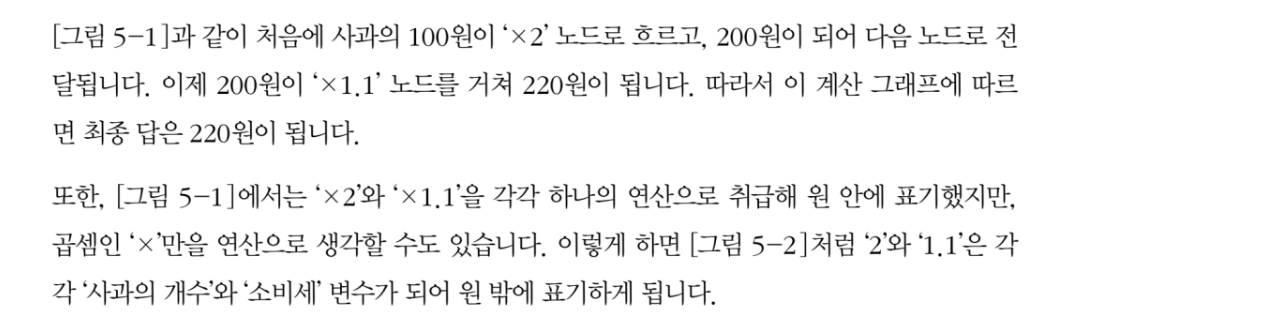

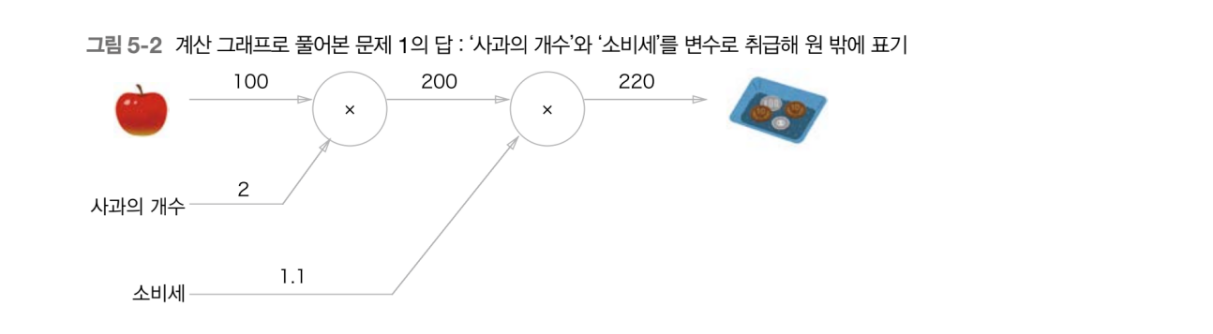

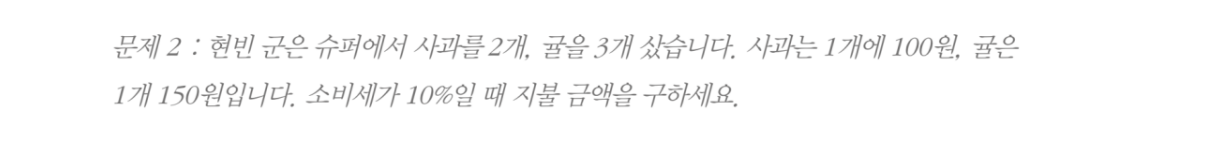

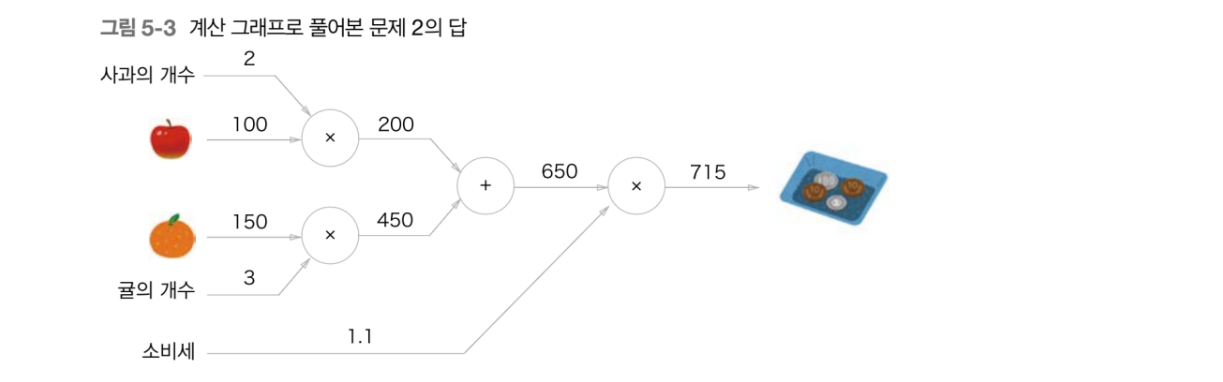

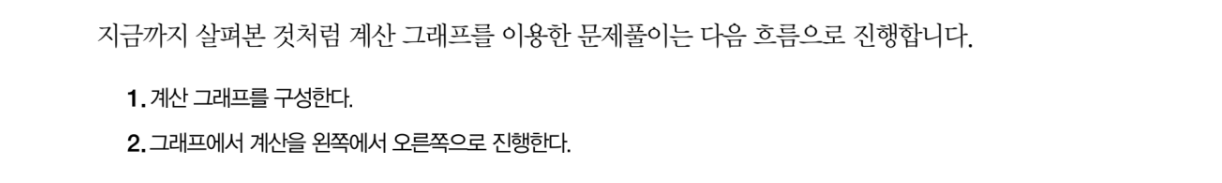

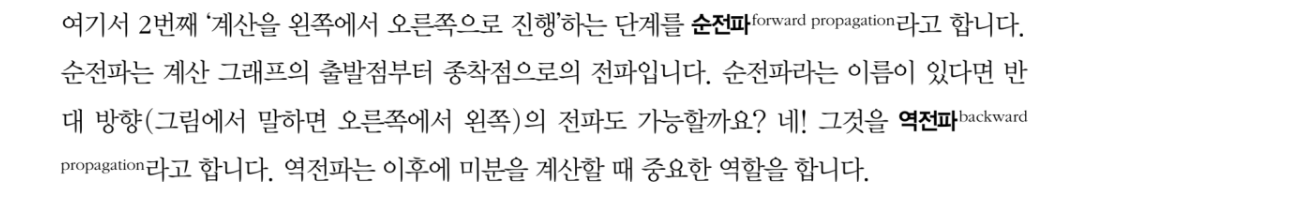

## 5.1.2 국소적 계산

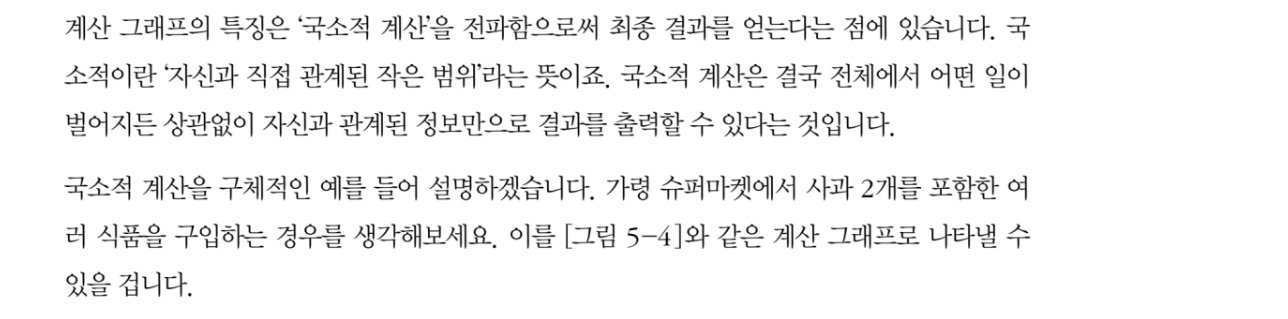

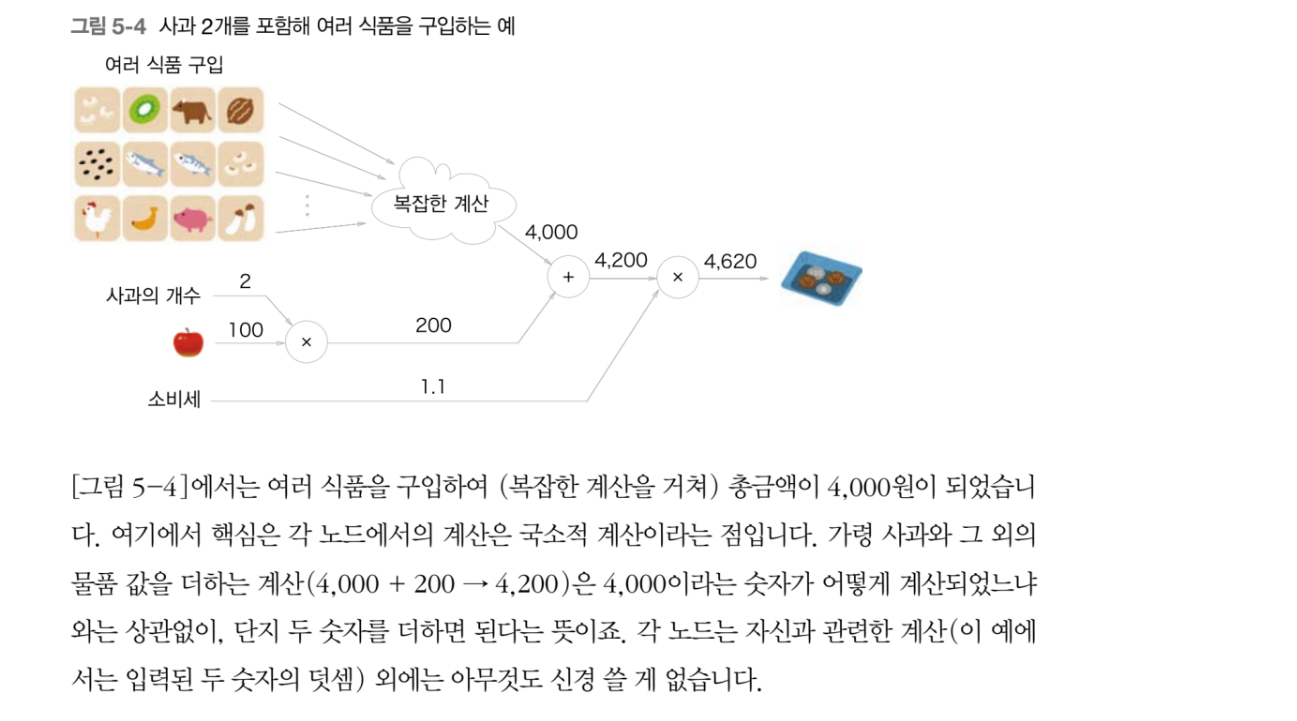

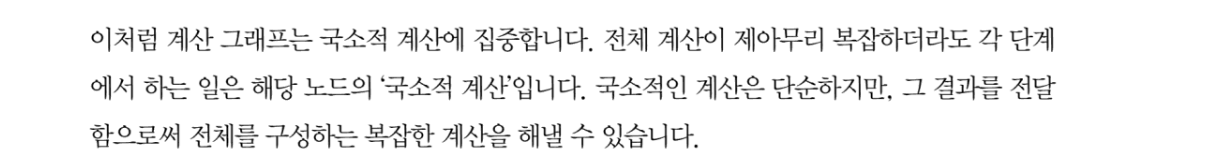

## 5.1.3 왜 계산 그래프로 푸는가?
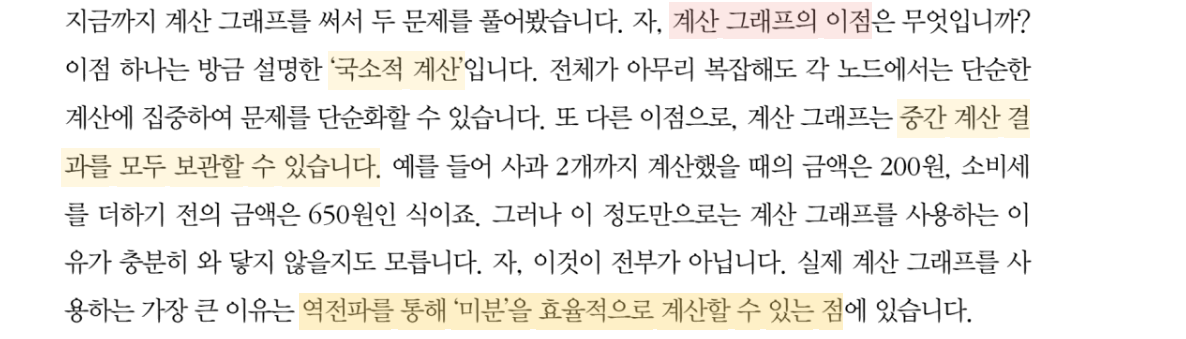
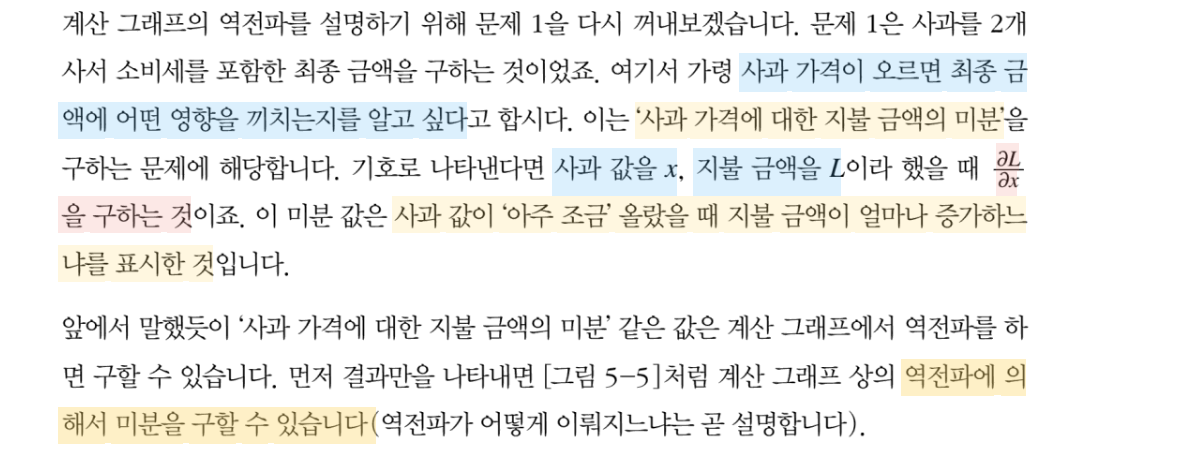

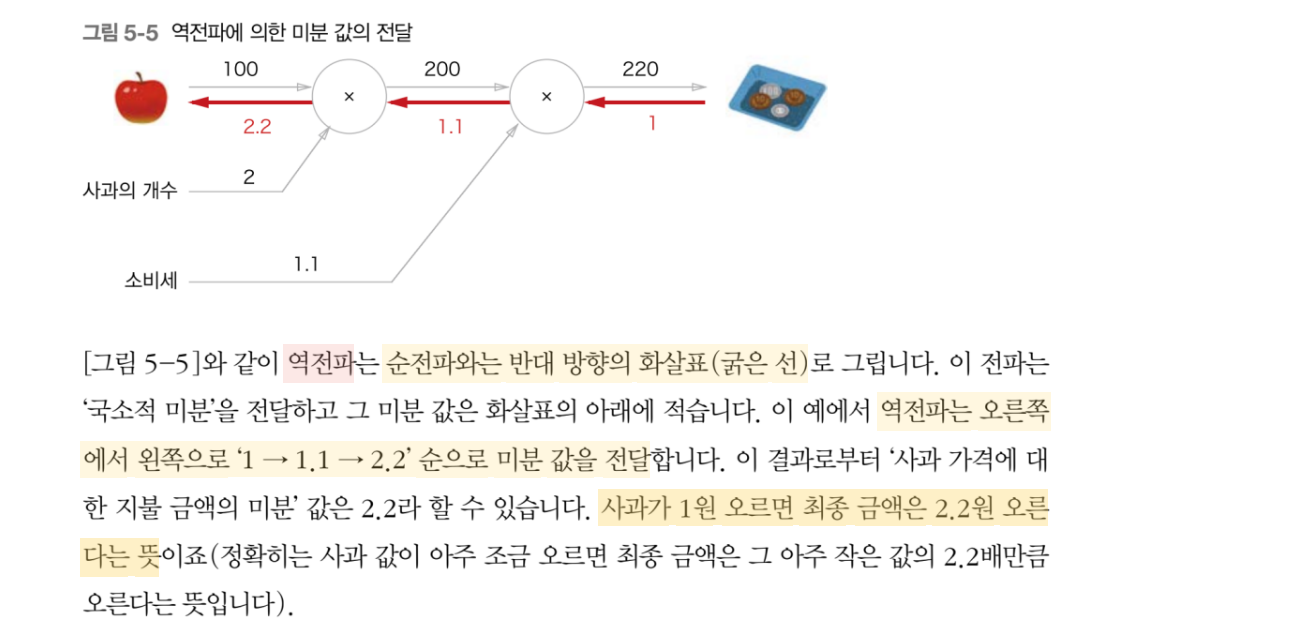
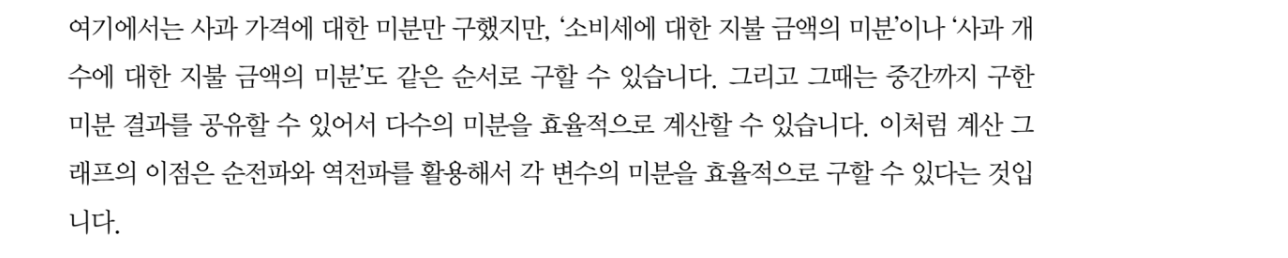

# 5.2 연쇄법칙
## 5.2.1 계산 그래프의 역전파
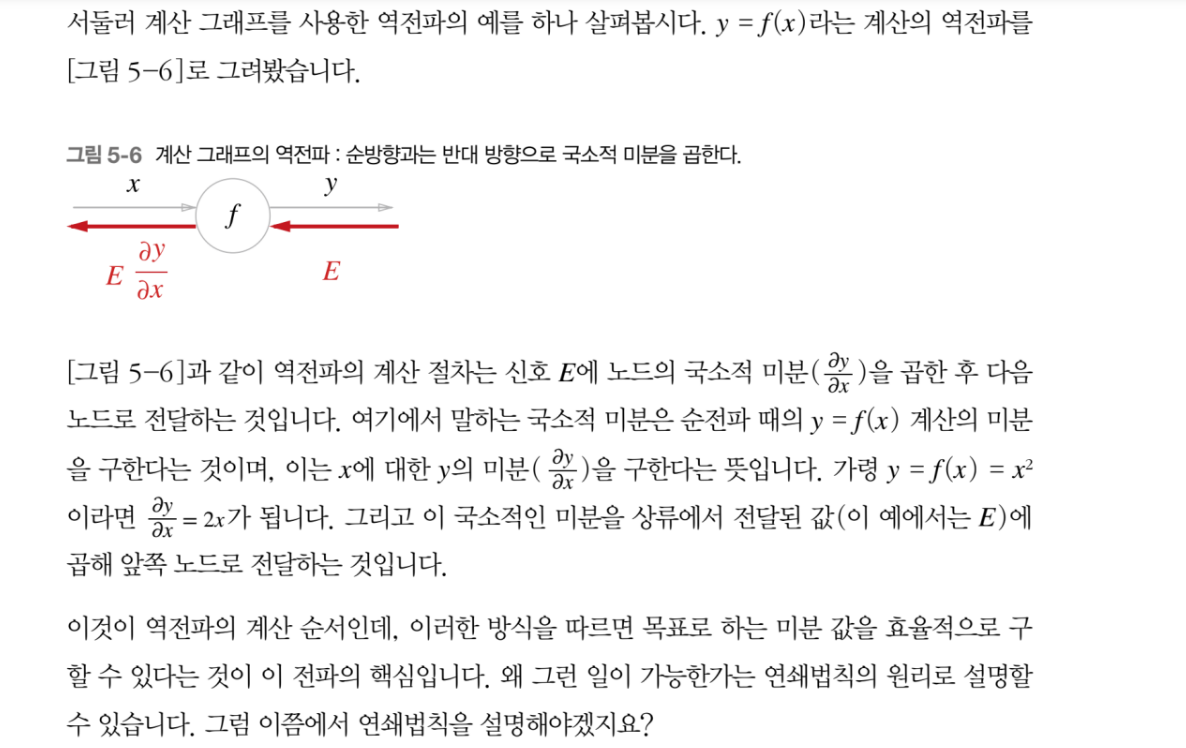

## 5.2.1 연쇄법칙이란?
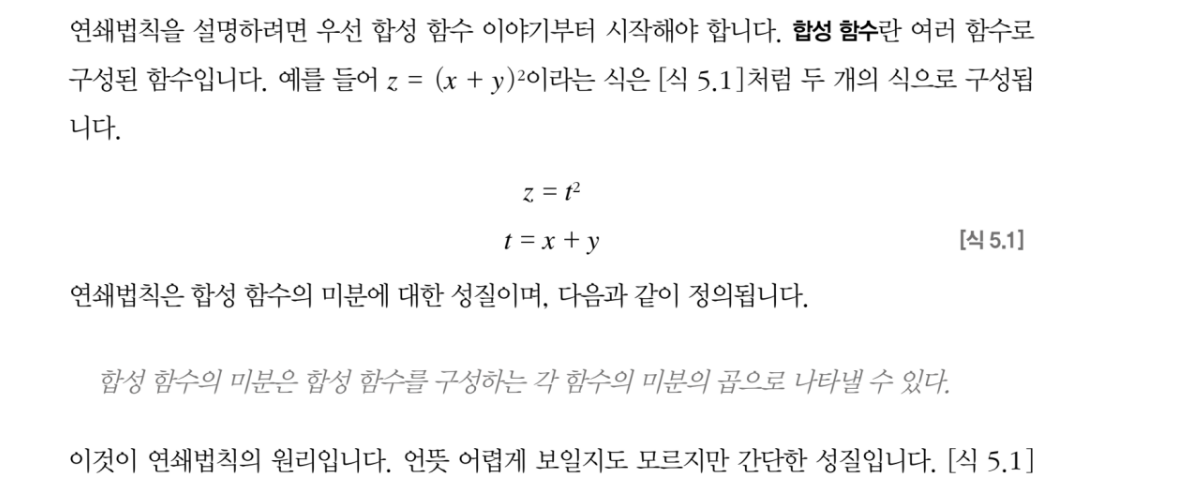
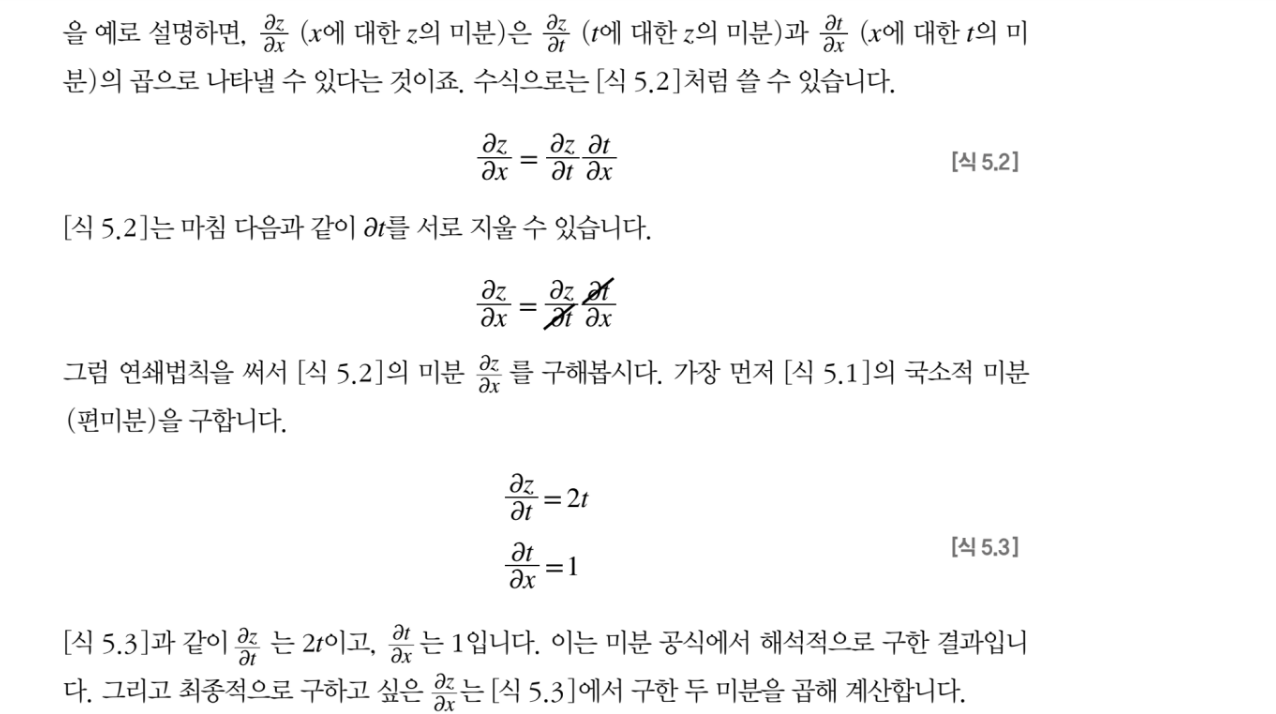
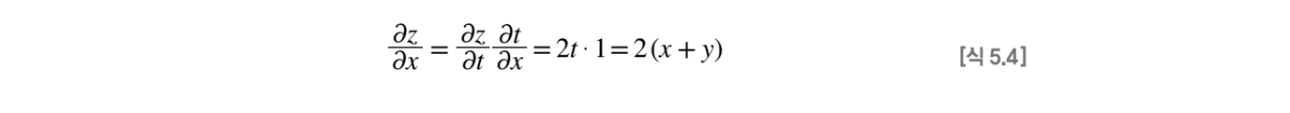
## 5.2.3 연쇄법칙과 계산 그래프
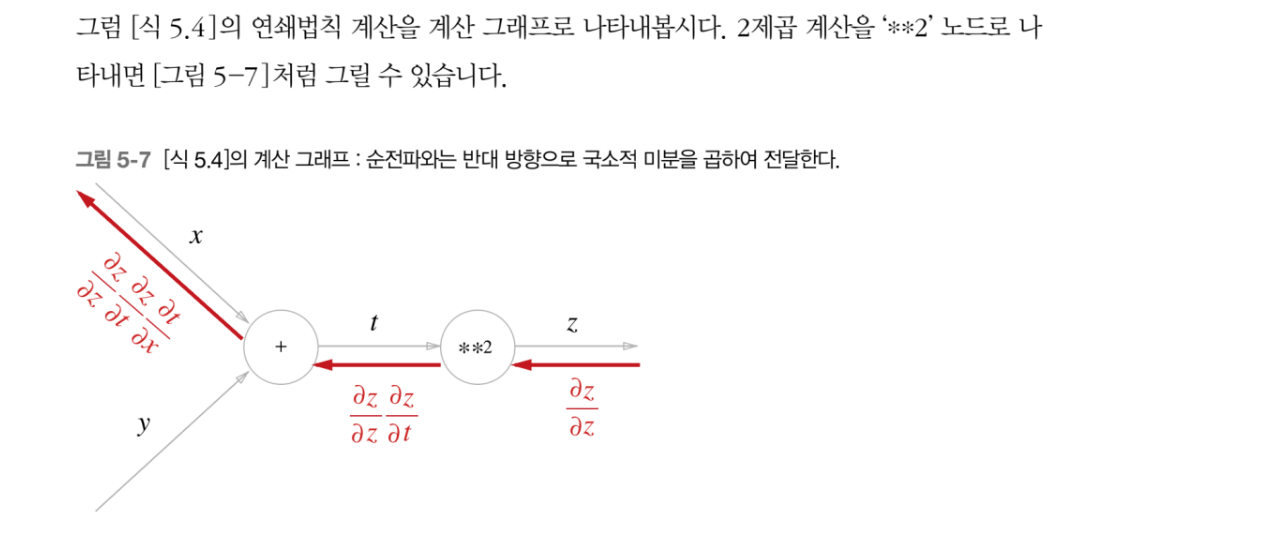

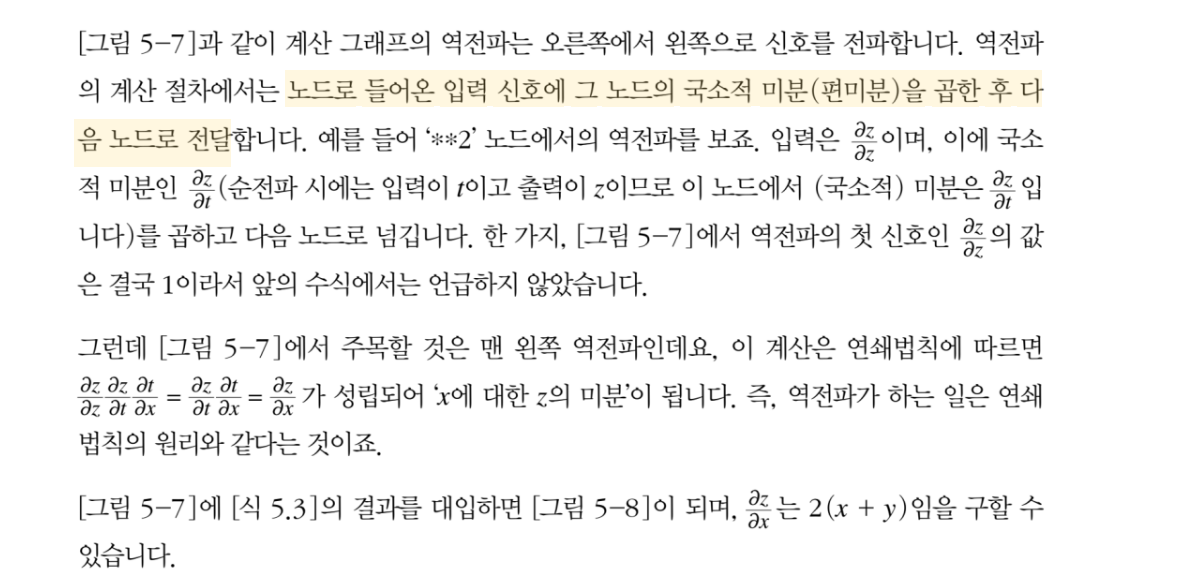
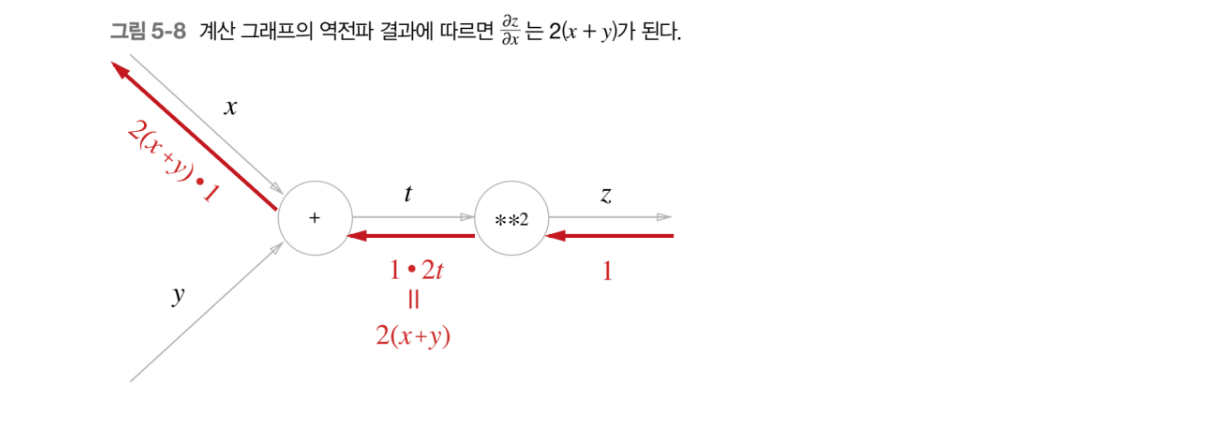

# 5.3 역전파
## 5.3.1 덧셈 노드의 역전파
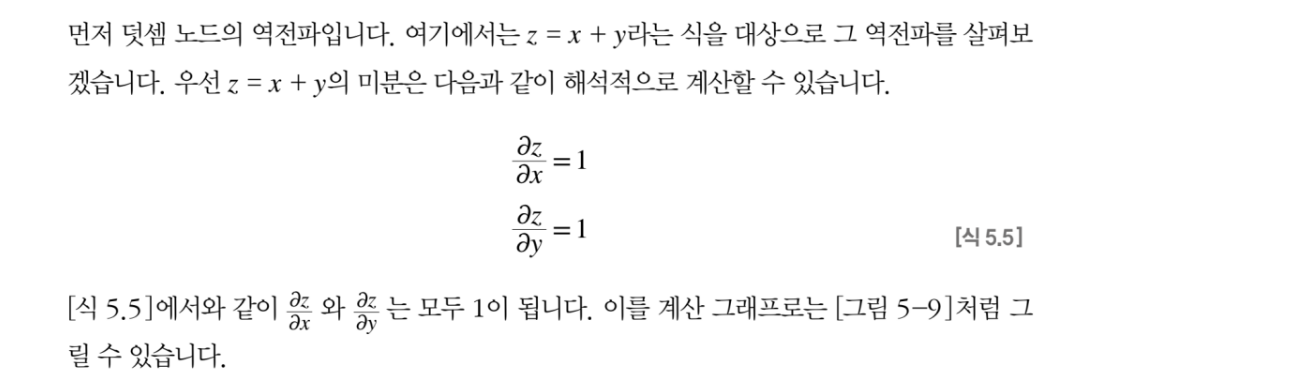

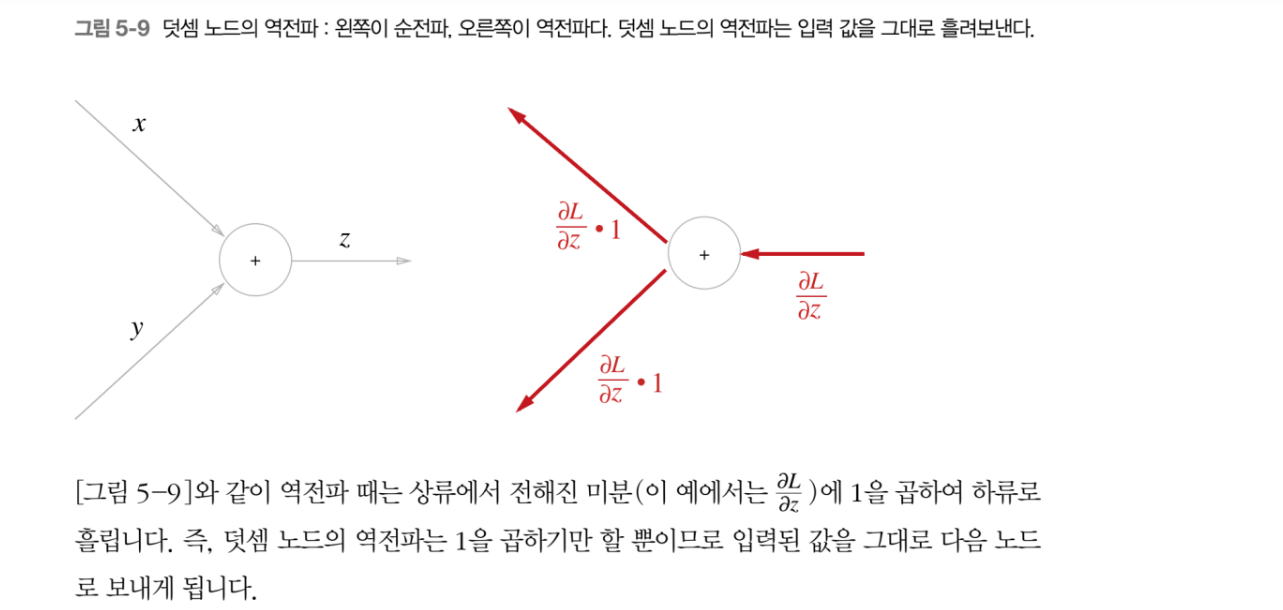

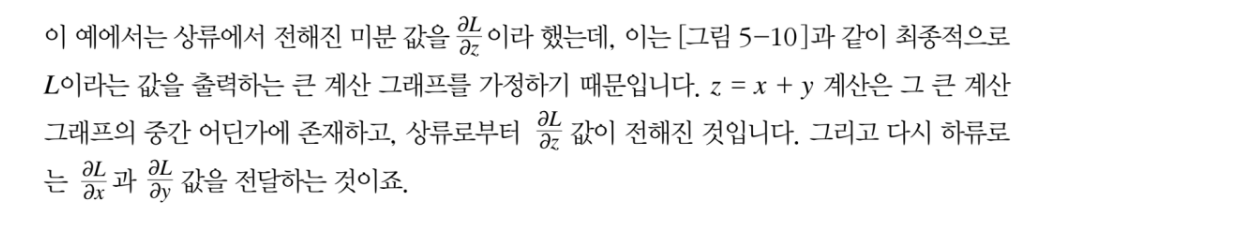

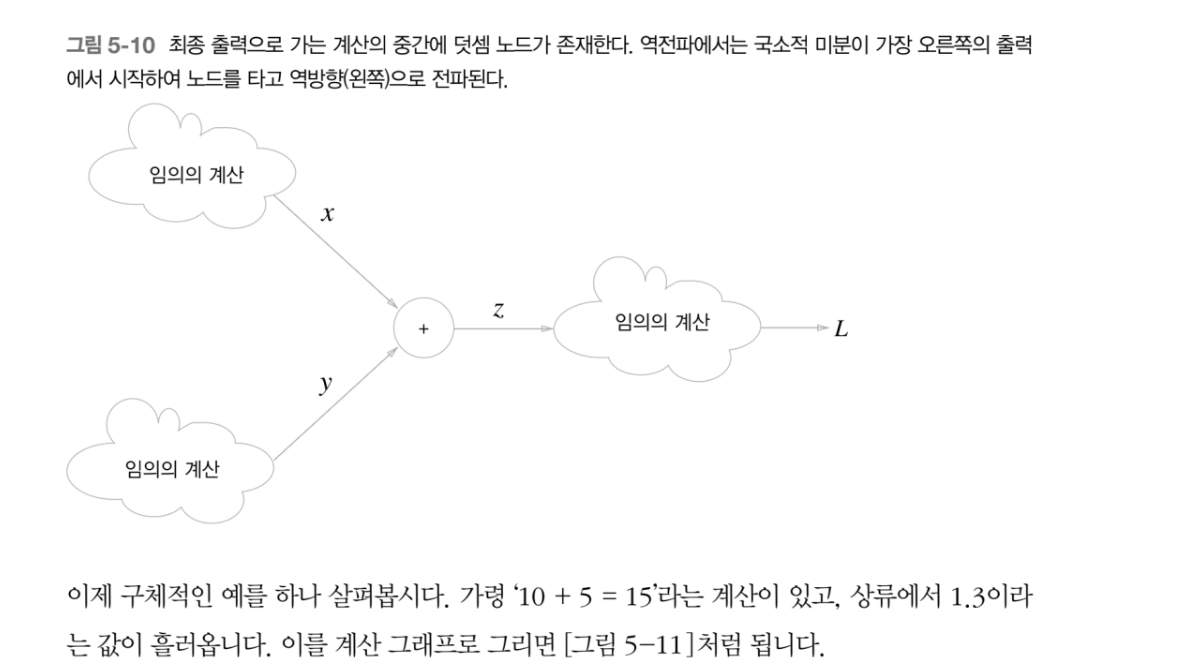
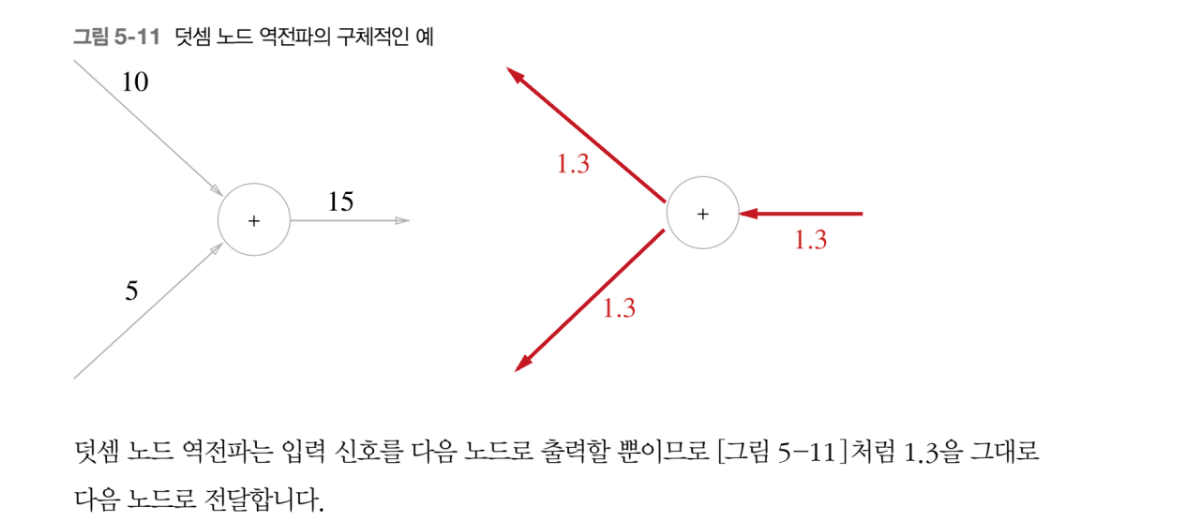

## 5.3.2 곱셈 노드의 역전파

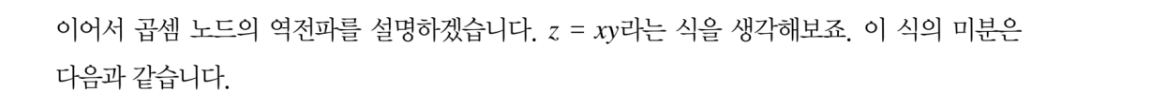
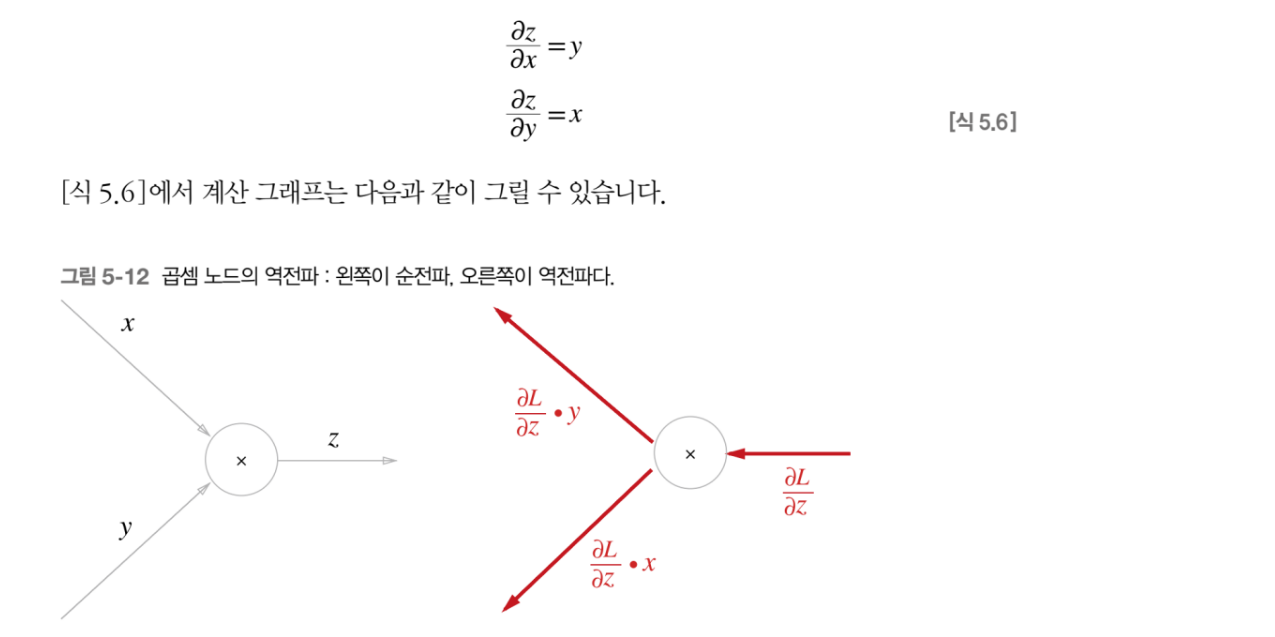

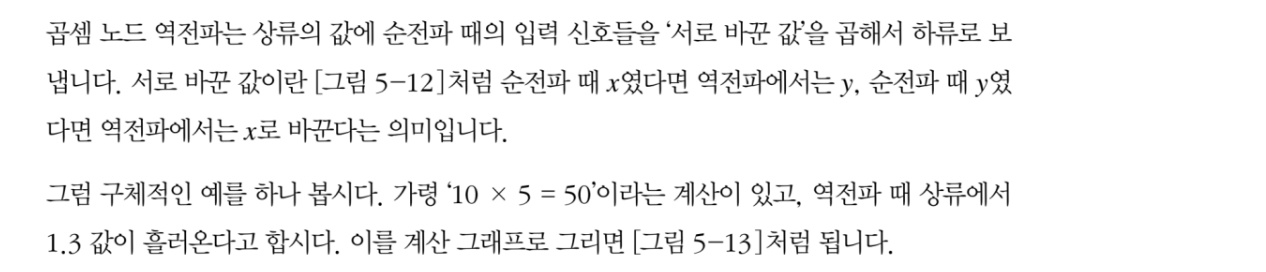
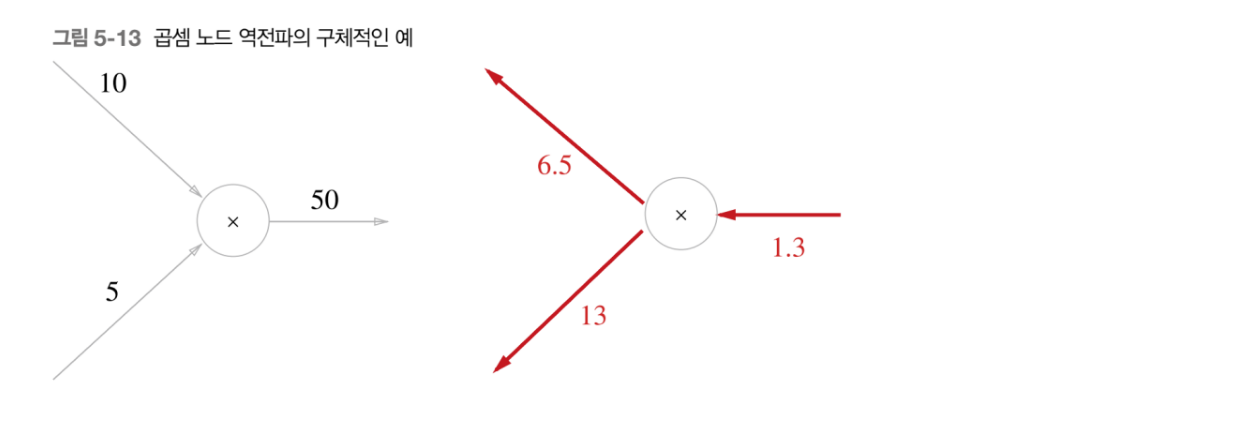
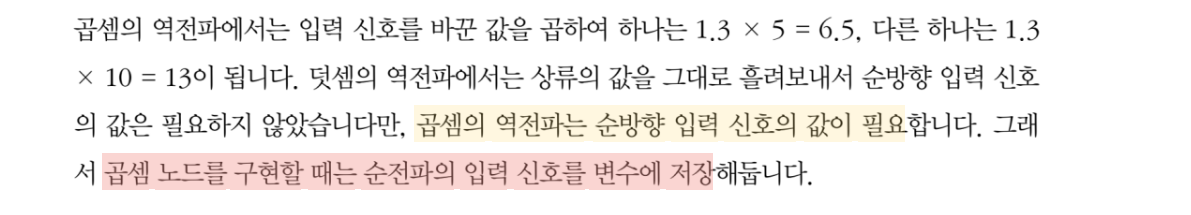

## 5.3.3 사과 쇼핑의 예
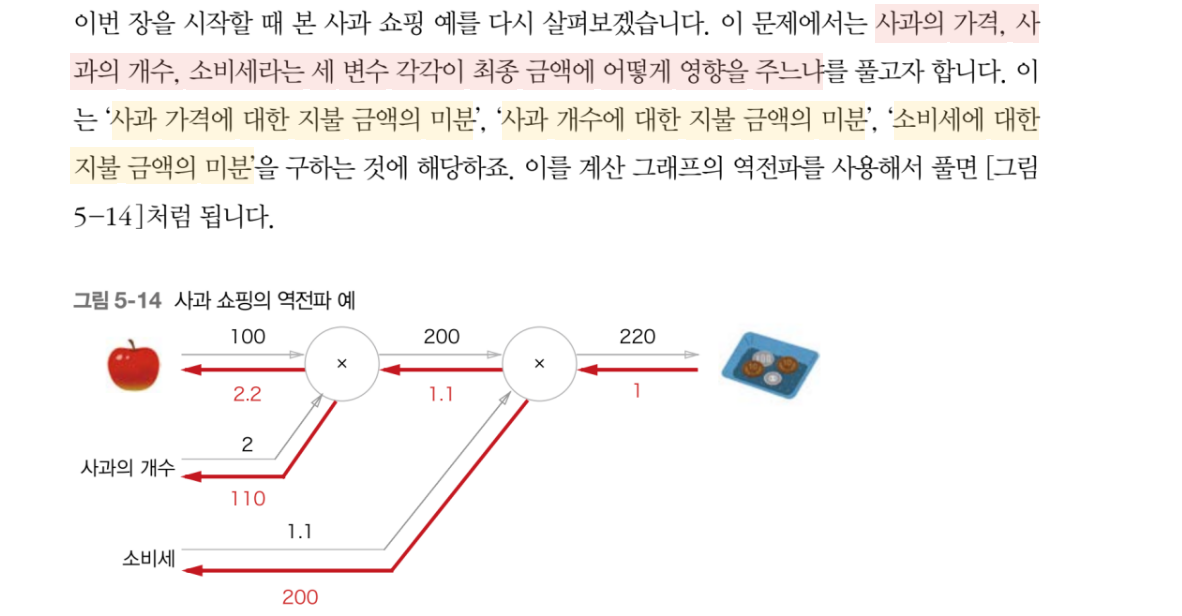
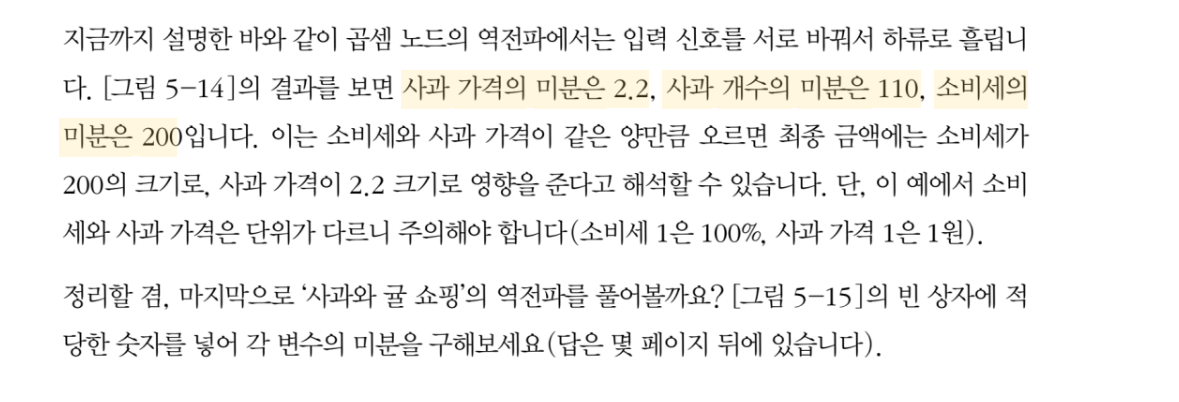
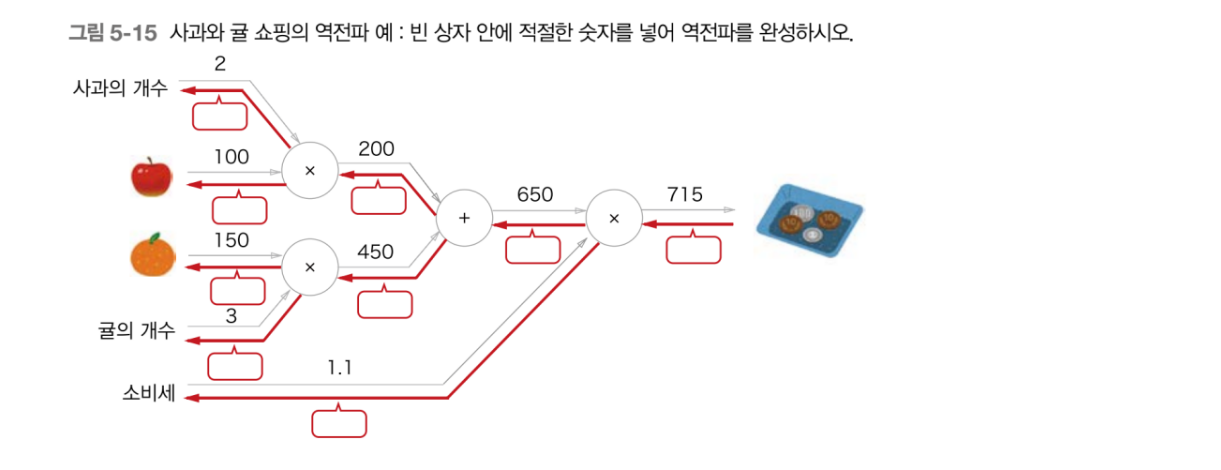

# 5.4 단순한 계층 구현하기

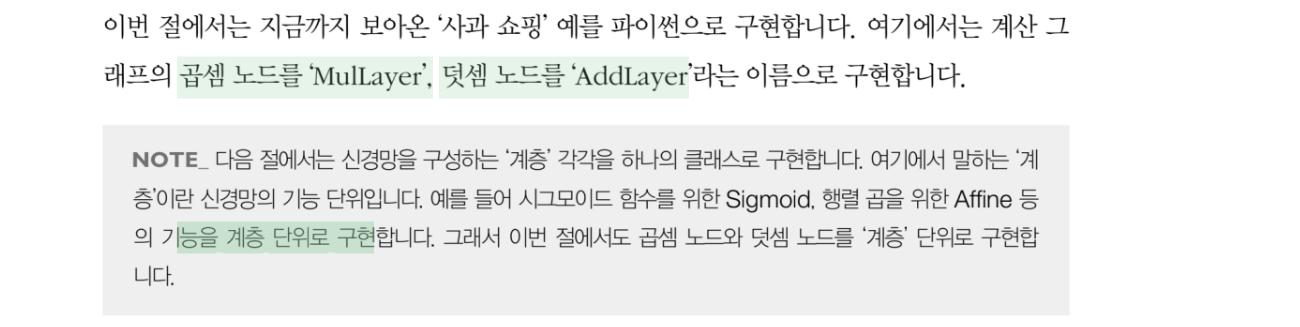

In [1]:
# 곱셈 레이어
class MulLayer:  
    def __init__(self):
        self.x = None
        self.y = None
        
    def forward(self, x, y):
        self.x = x
        self.y = y
        out = x * y
        
        return out
    
    def backward(self, dout):
        dx = dout * self.y # x와 y를 바꾼다
        dy = dout * self.x
        
        return dx, dy

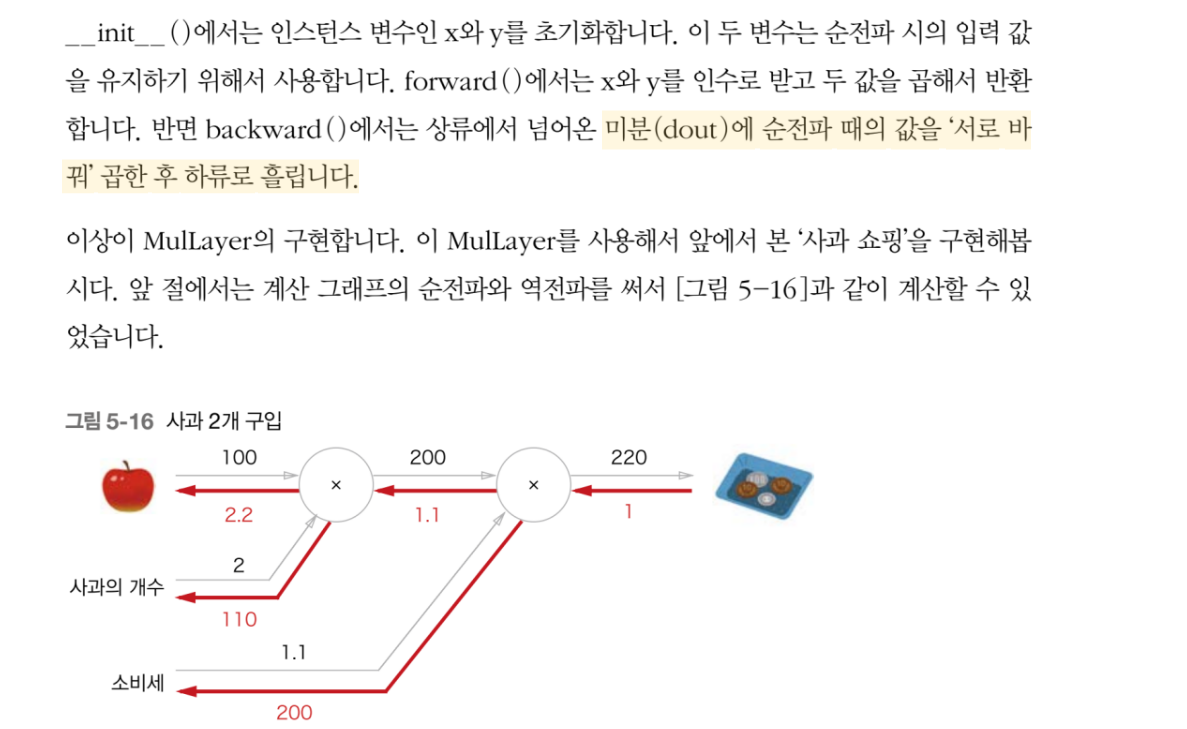

In [2]:
apple = 100
apple_num = 2
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
apple_price

200

In [3]:
price = mul_tax_layer.forward(apple_price, tax)
price

220.00000000000003

In [4]:
###############################
# 역전파
###############################
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple_price, dtax

(1.1, 200)

In [5]:
dapple, dapple_num = mul_apple_layer.backward(dapple_price)
dapple, dapple_num, dtax

(2.2, 110.00000000000001, 200)

## 5.4.1 덧셈 계층

In [6]:
class AddLayer:
    def __init__(self):
        pass
    
    def forward(self, x, y):
        out = x + y
        return out
    
    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy

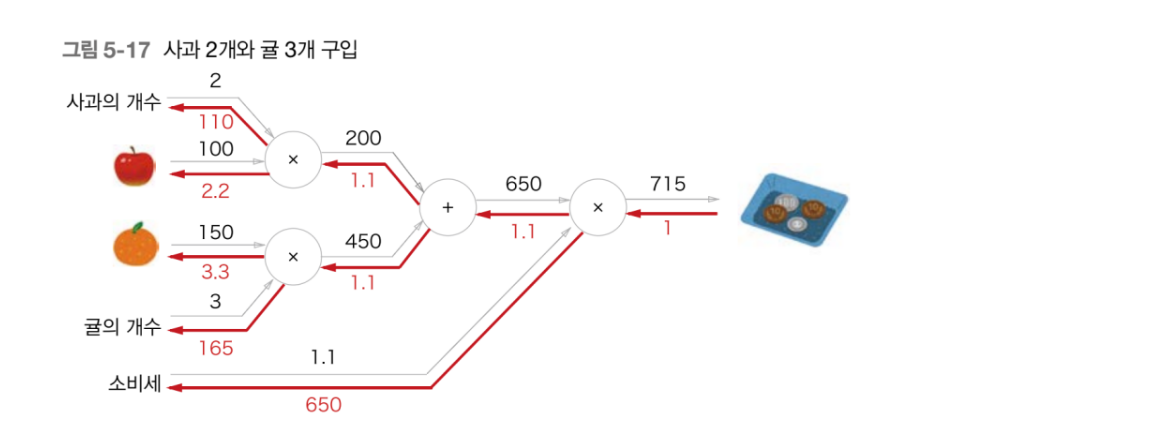

In [7]:
apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
apple_price

200

In [8]:
orange_price = mul_orange_layer.forward(orange, orange_num)
orange_price

450

In [9]:
apple_orange_price = add_apple_orange_layer.forward(apple_price, orange_price)
apple_orange_price

650

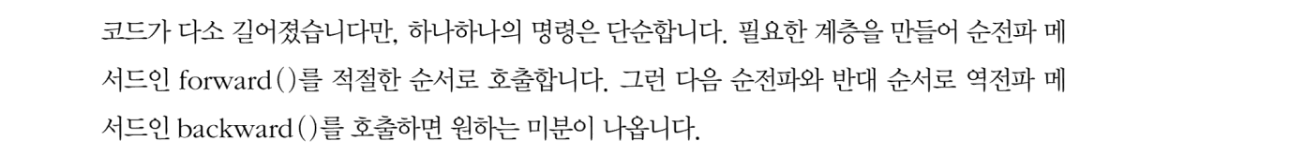

# 5.5  활성화 함수 계층 구현하기
## 5.5.1 ReLU 계층
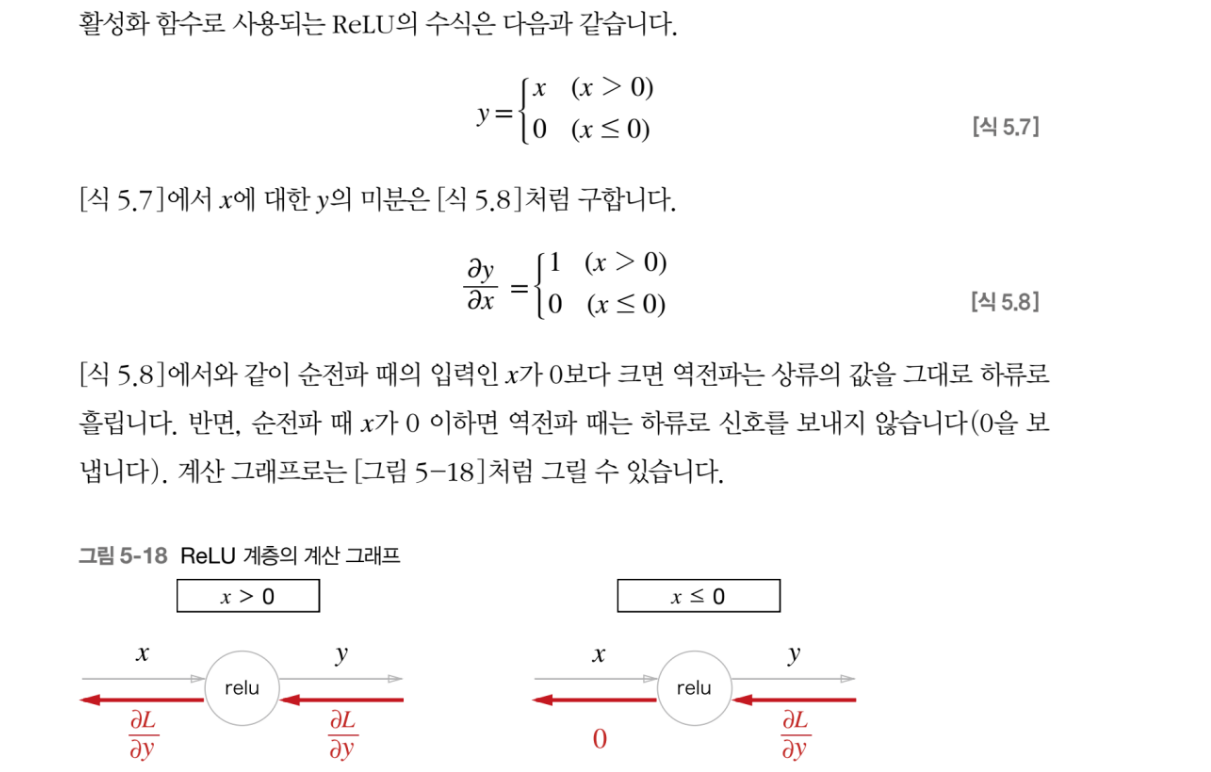

In [10]:
class Relu:
    def __init__(self):
        self.mask = None
    
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0   # 0보다 작은 요소를 모두 0으로
    
        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        
        return dx      

In [11]:
## mask라는 인스턴스 변수 설명
import numpy as np
x = np.array([[1.0, -0.5], [-2.0, 3.0]])
print(x)

[[ 1.  -0.5]
 [-2.   3. ]]


In [12]:
mask = (x <= 0)
mask

array([[False,  True],
       [ True, False]])

In [13]:
relu = Relu()
y = relu.forward(x)
y

array([[1., 0.],
       [0., 3.]])

In [14]:
dout = np.array([[1, 2], [3, 4]])
dx = relu.backward(dout)
dx

array([[1, 0],
       [0, 4]])

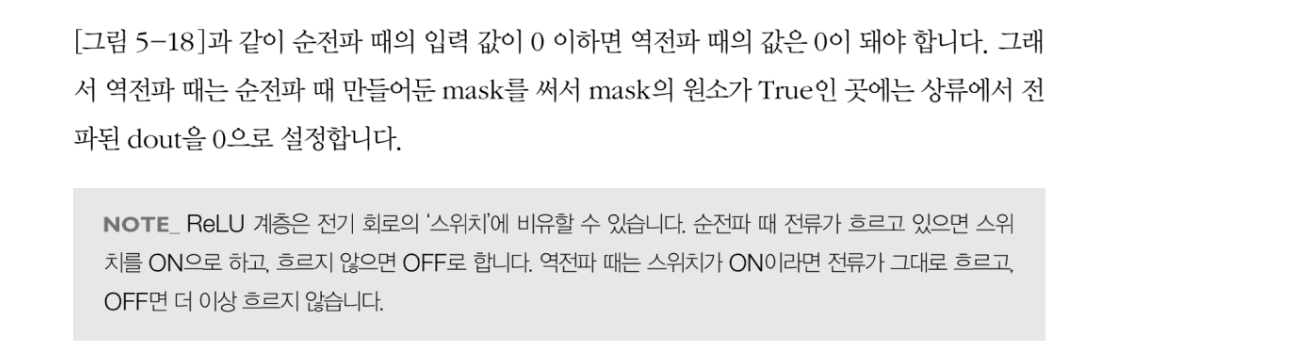

## 5.5.2 Sigmoid 계층
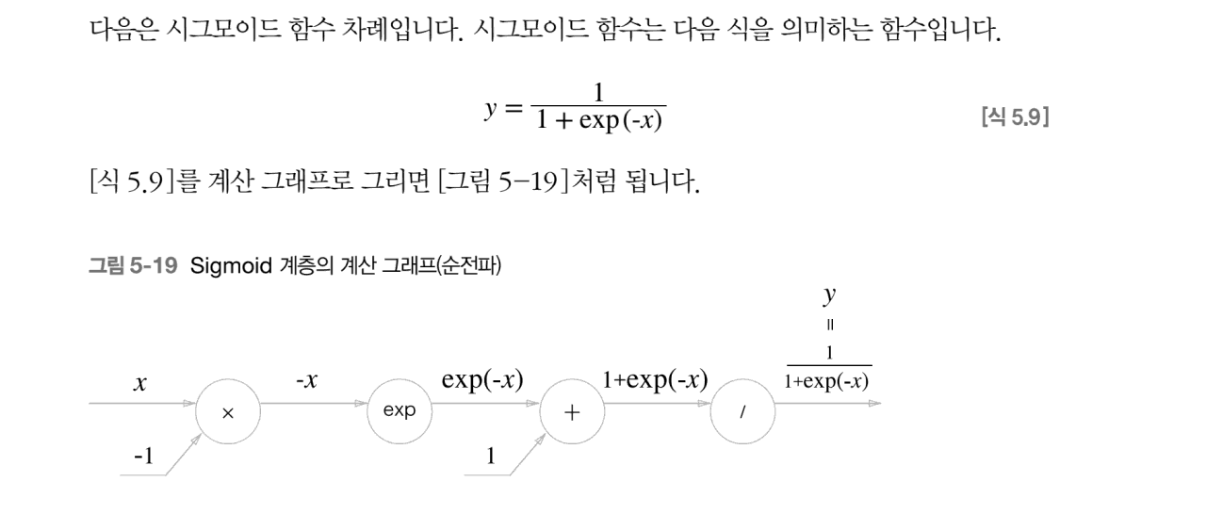

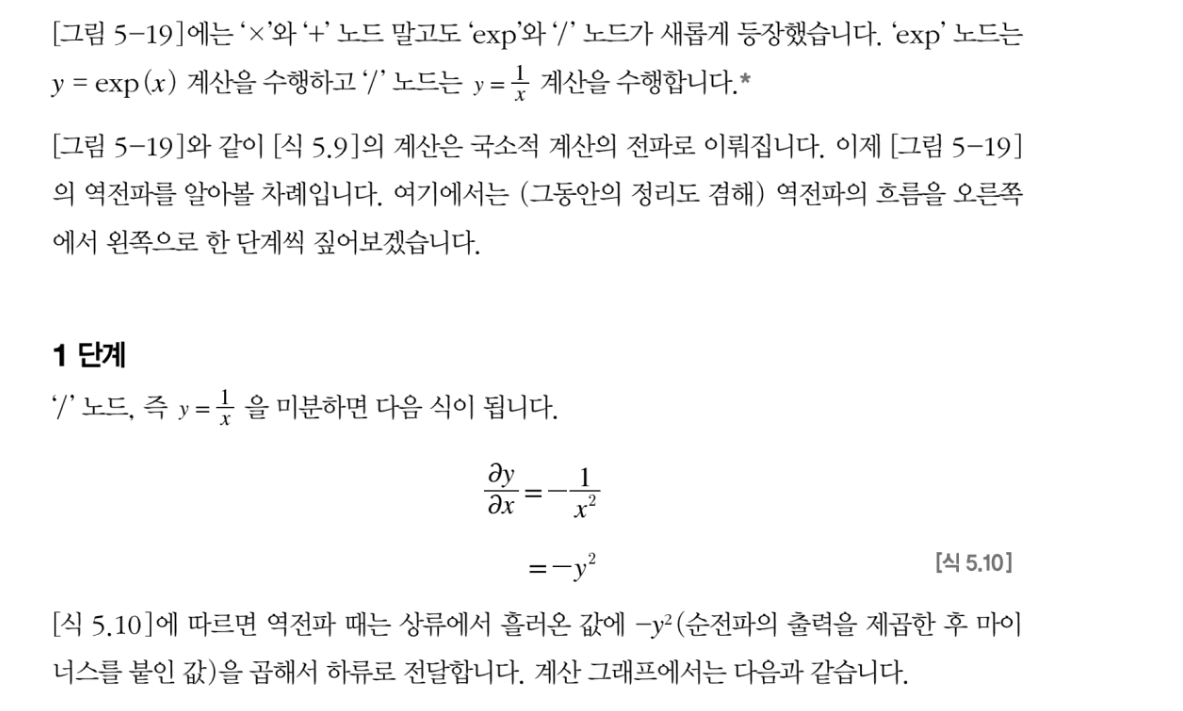
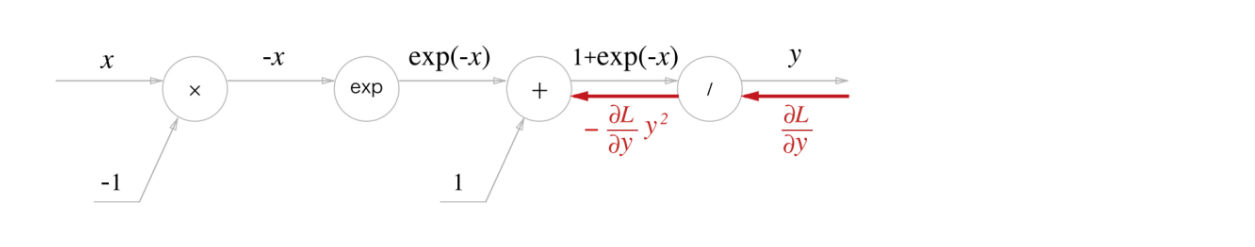

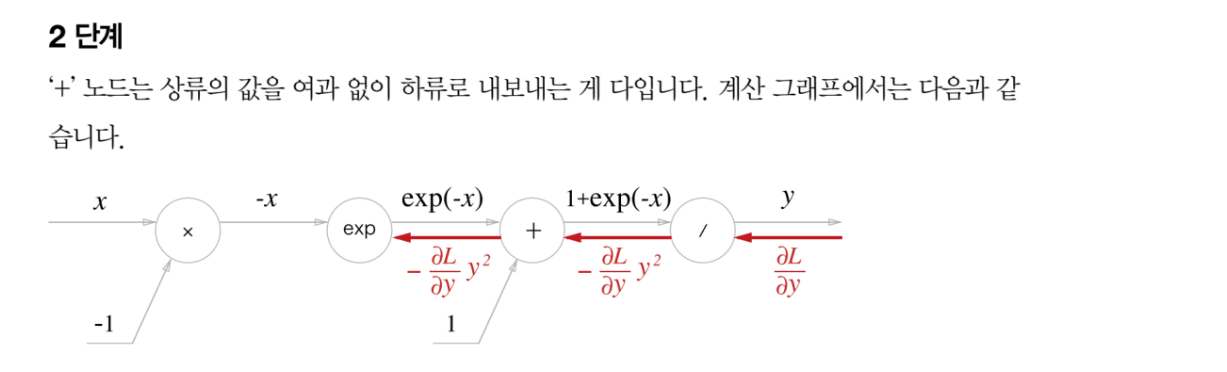

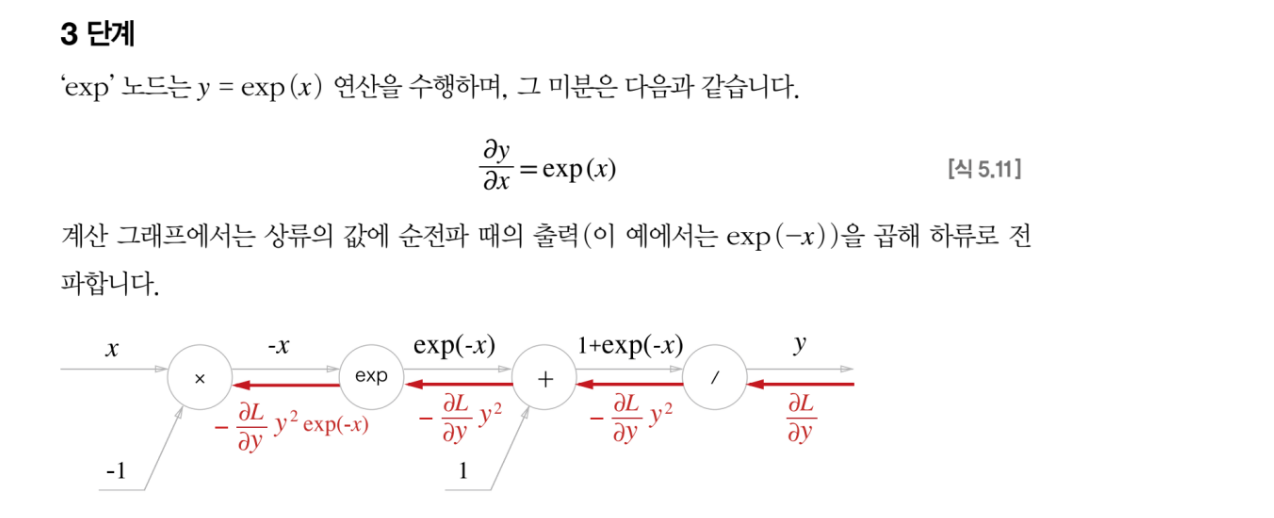

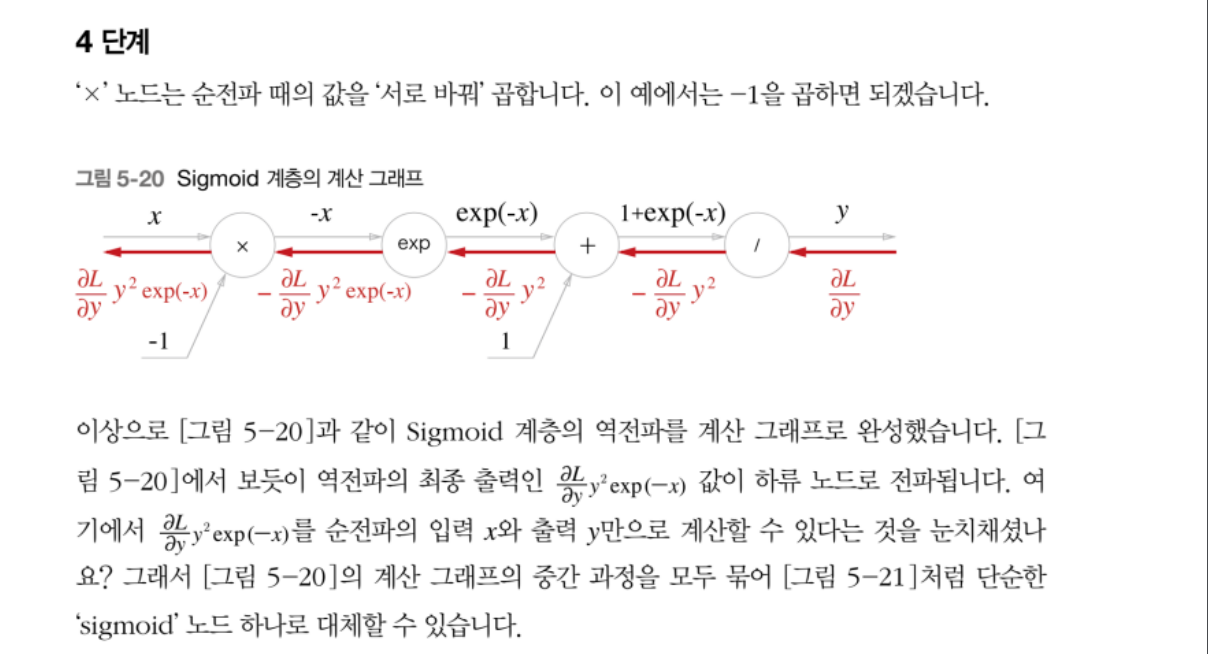

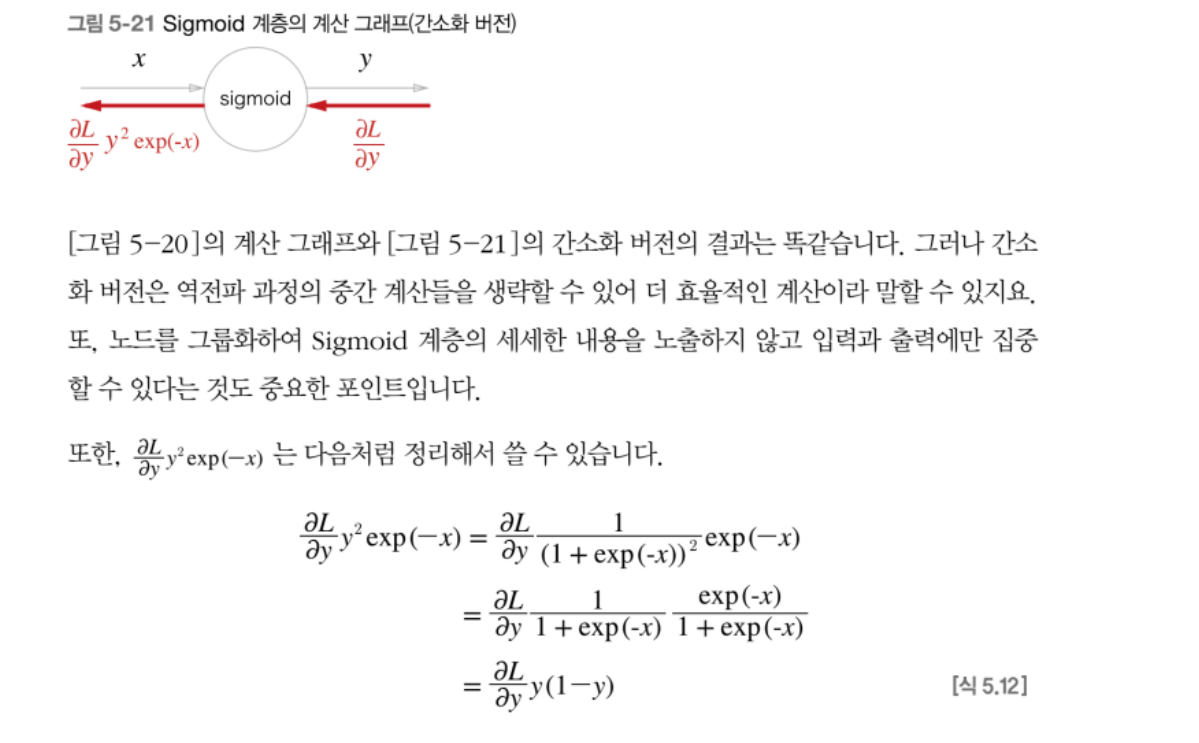
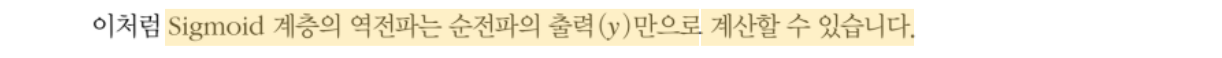
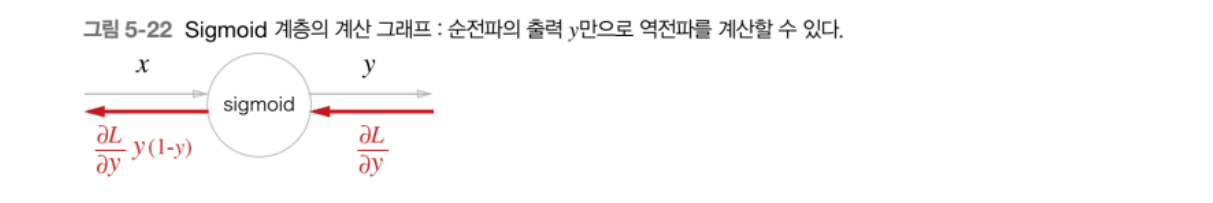

In [15]:
## sigmoid 계층
class Sigmoid:
    def __init__(self):
        self.out = None
        
    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out ## 인스턴스 변수 out에 보관 (역전파 때 사용) 
        return out
    
    def backward(self, dout):
        dx = dout * self.out * (1.0 - self.out)
        
        return dx        

In [16]:
## x = 0.5 일때...
sigmoid = Sigmoid()
x = np.arange(-5, 5, 0.2)
y = sigmoid.forward(x)
y

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743])

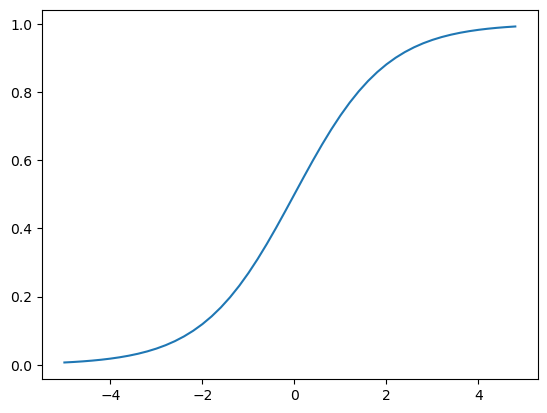

In [17]:
import matplotlib.pyplot as plt
plt.plot(x, y)
plt.show()

In [18]:
dx = sigmoid.backward(1)
dx

array([0.00664806, 0.00809594, 0.00985276, 0.01198134, 0.01455576,
       0.01766271, 0.02140248, 0.02588959, 0.03125247, 0.03763177,
       0.04517666, 0.05403811, 0.0643583 , 0.076255  , 0.08980033,
       0.10499359, 0.12172934, 0.13976379, 0.1586849 , 0.17789444,
       0.19661193, 0.2139097 , 0.22878424, 0.24026075, 0.24751657,
       0.25      , 0.24751657, 0.24026075, 0.22878424, 0.2139097 ,
       0.19661193, 0.17789444, 0.1586849 , 0.13976379, 0.12172934,
       0.10499359, 0.08980033, 0.076255  , 0.0643583 , 0.05403811,
       0.04517666, 0.03763177, 0.03125247, 0.02588959, 0.02140248,
       0.01766271, 0.01455576, 0.01198134, 0.00985276, 0.00809594])

# 5.6 Affine / Softmax 계층 구현하기
## 5.6.1 Affine 계층

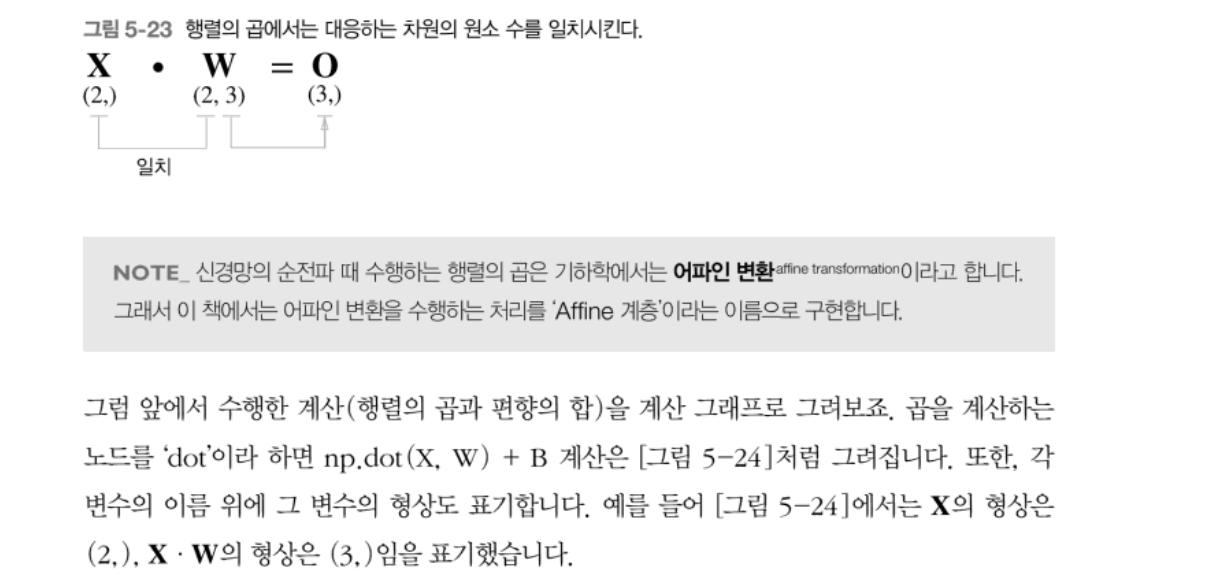
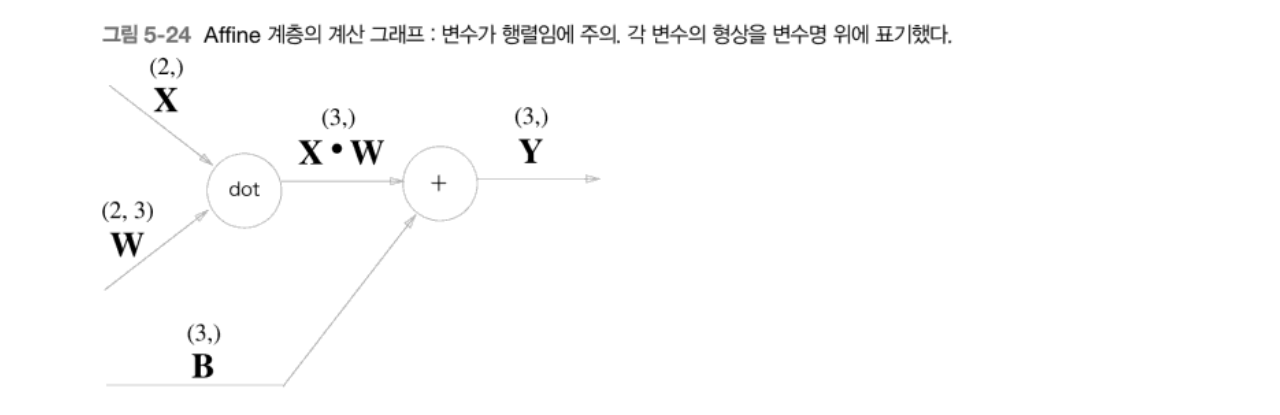

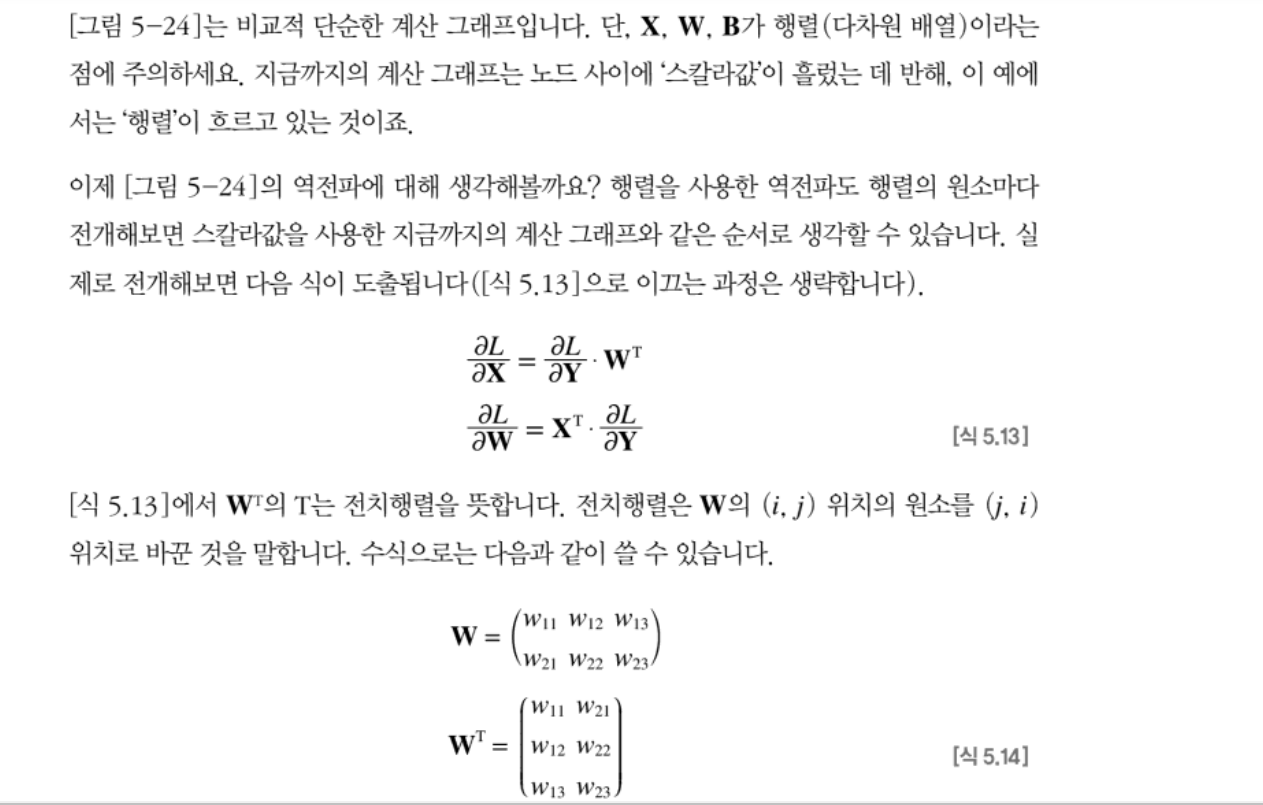
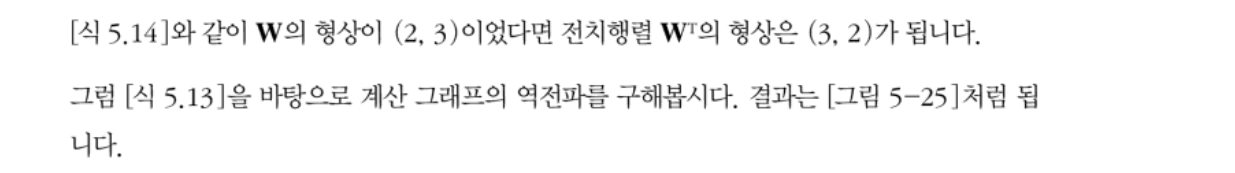

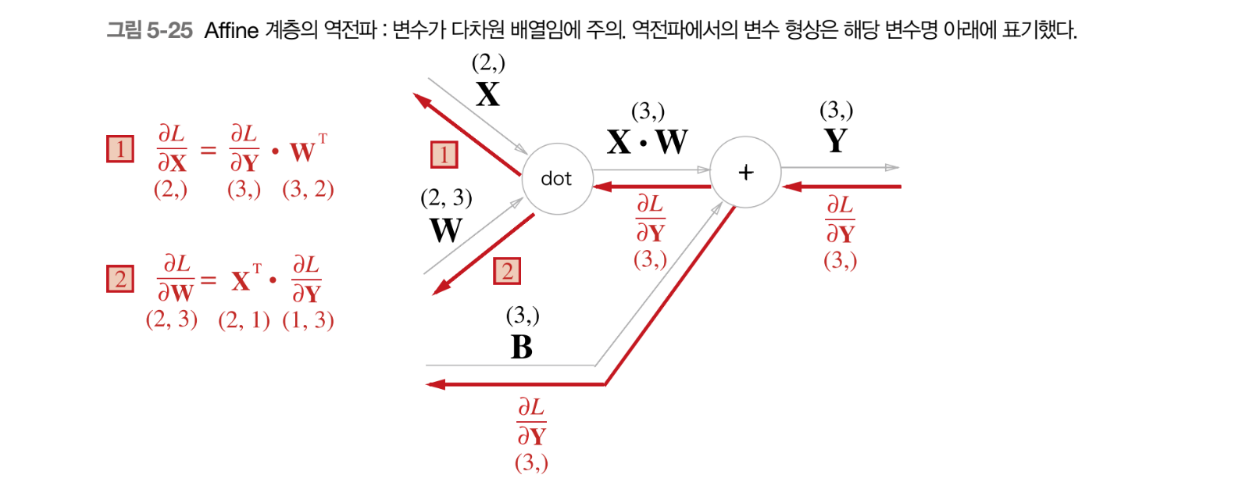

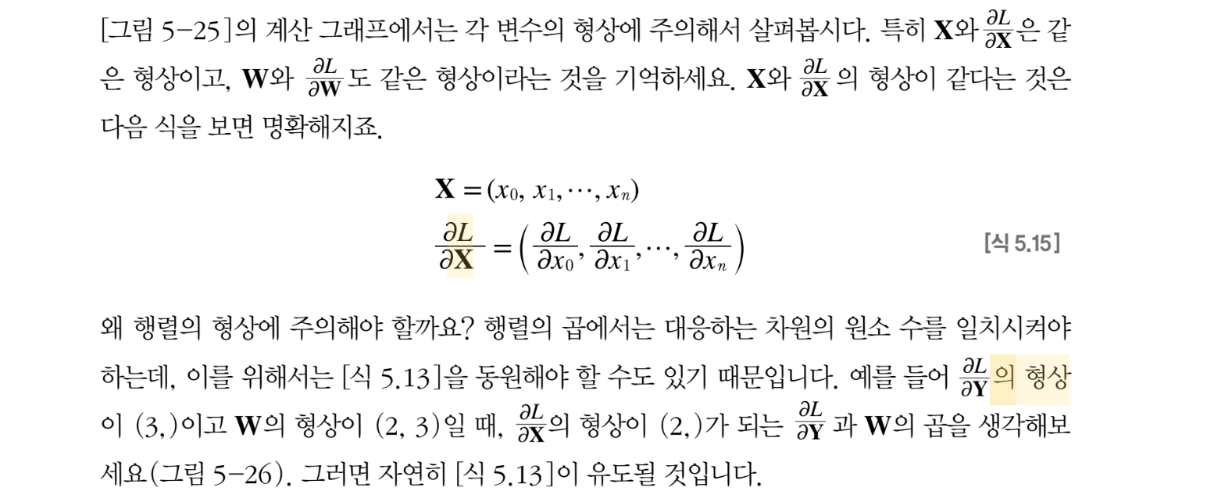
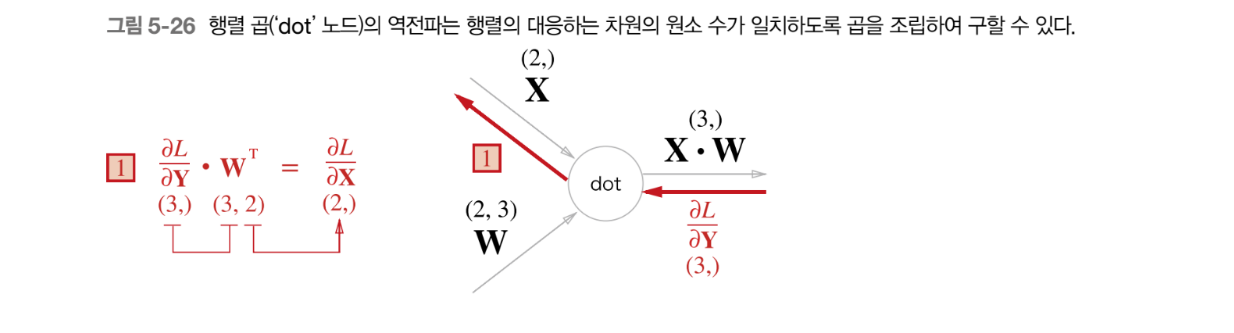

## 5.6.2 배치용 Affine 계층
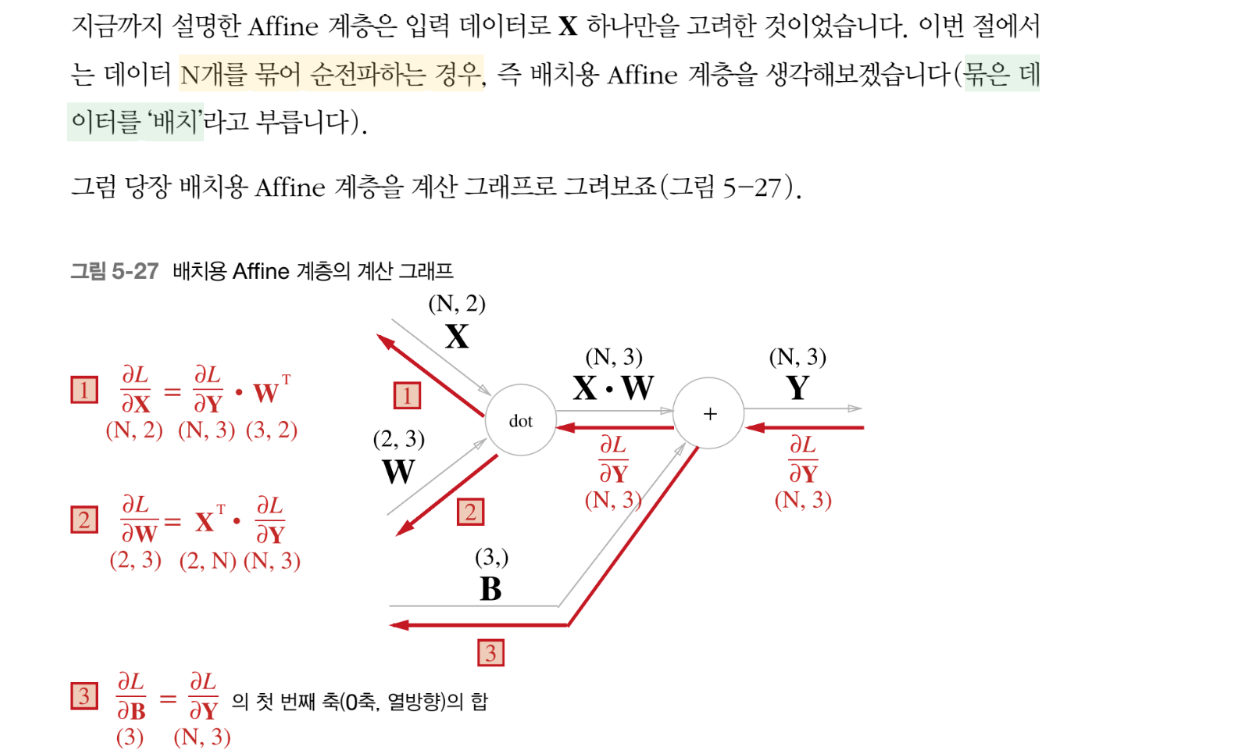
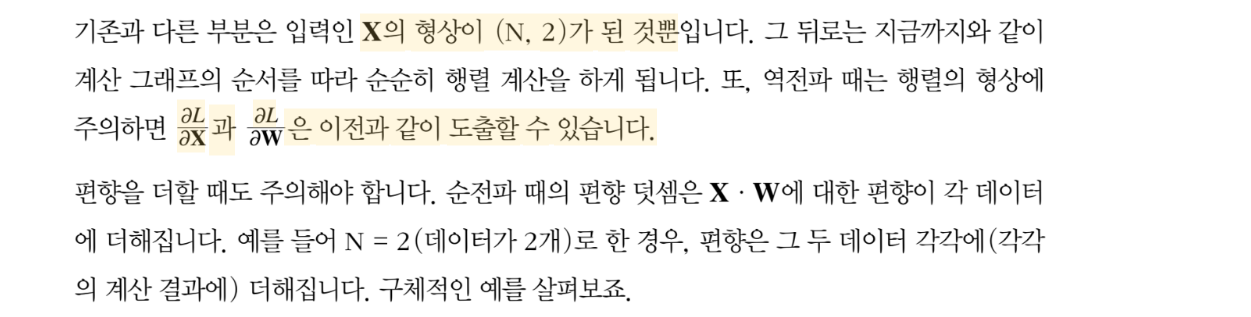

In [19]:
X_dot_W = np.array([[0, 0, 0], [10, 10, 10]])
B = np.array([1, 2, 3])

X_dot_W

array([[ 0,  0,  0],
       [10, 10, 10]])

In [20]:
X_dot_W + B   # Broadcasting

array([[ 1,  2,  3],
       [11, 12, 13]])

In [21]:
dY = np.array([[1, 2, 3], [4, 5, 6]])
dY

array([[1, 2, 3],
       [4, 5, 6]])

In [22]:
dB = np.sum(dY, axis=0)
dB

array([5, 7, 9])

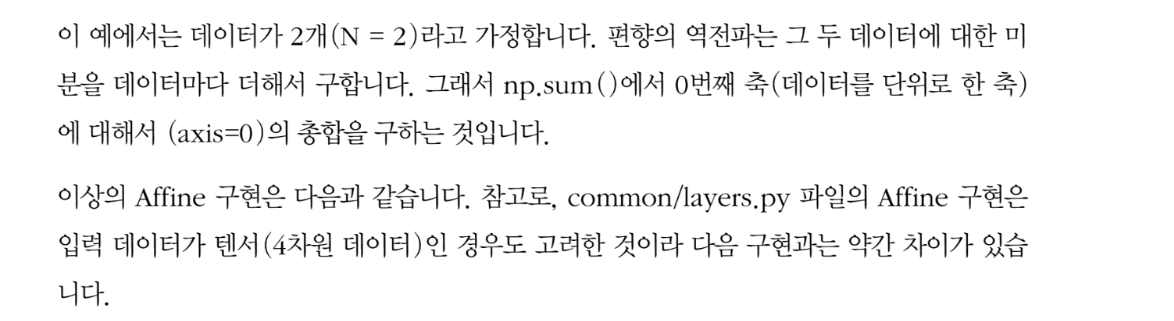

In [23]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None
        
    def forward(self, x):
        self.x = x
        out = np.dow(x, self.W) + self.b
        
        return out
    
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self, x.T, dout)
        self.db = np.sum(dout, axis=0)
        
        return dx

## 5.6.3 Softmax-with-Loss 계층

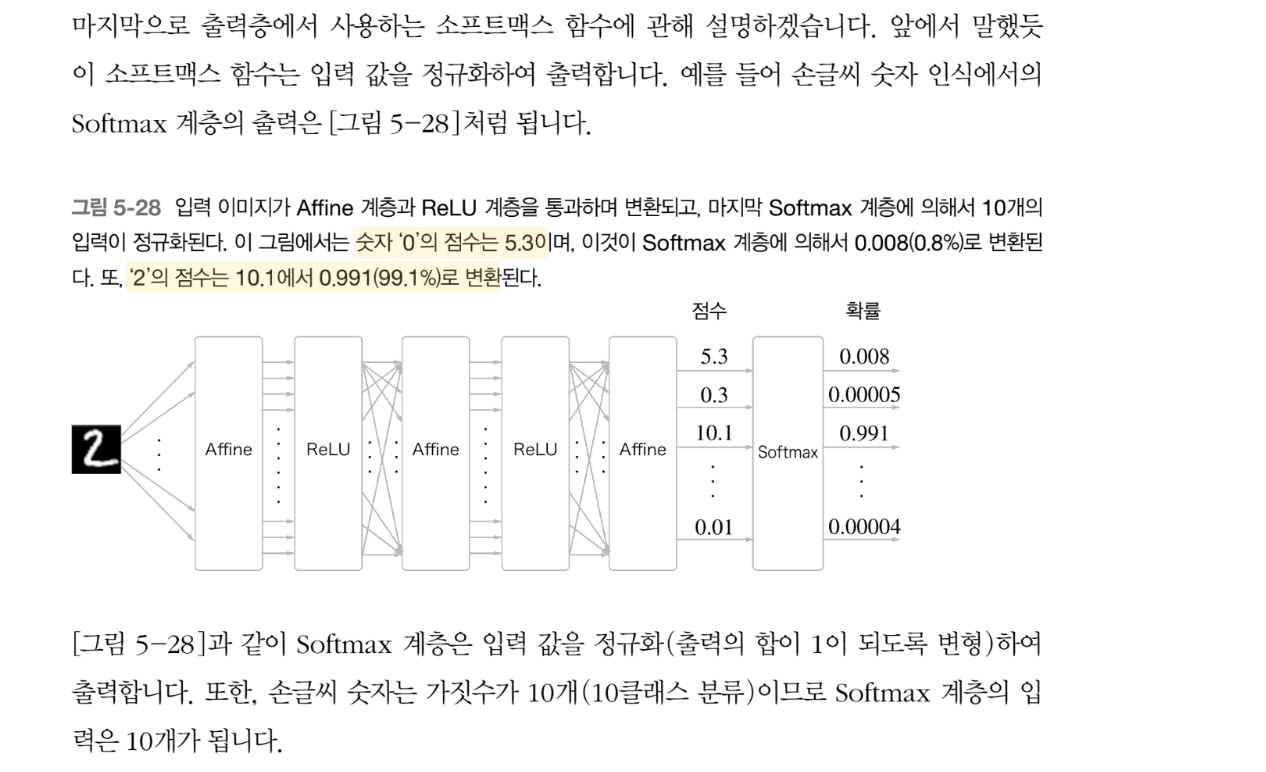
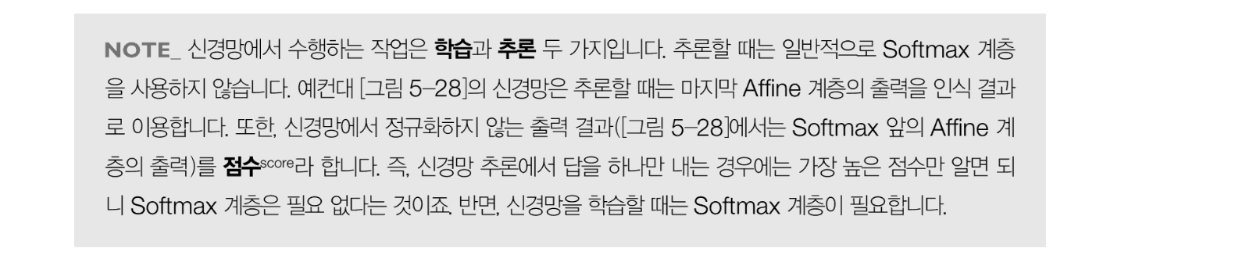

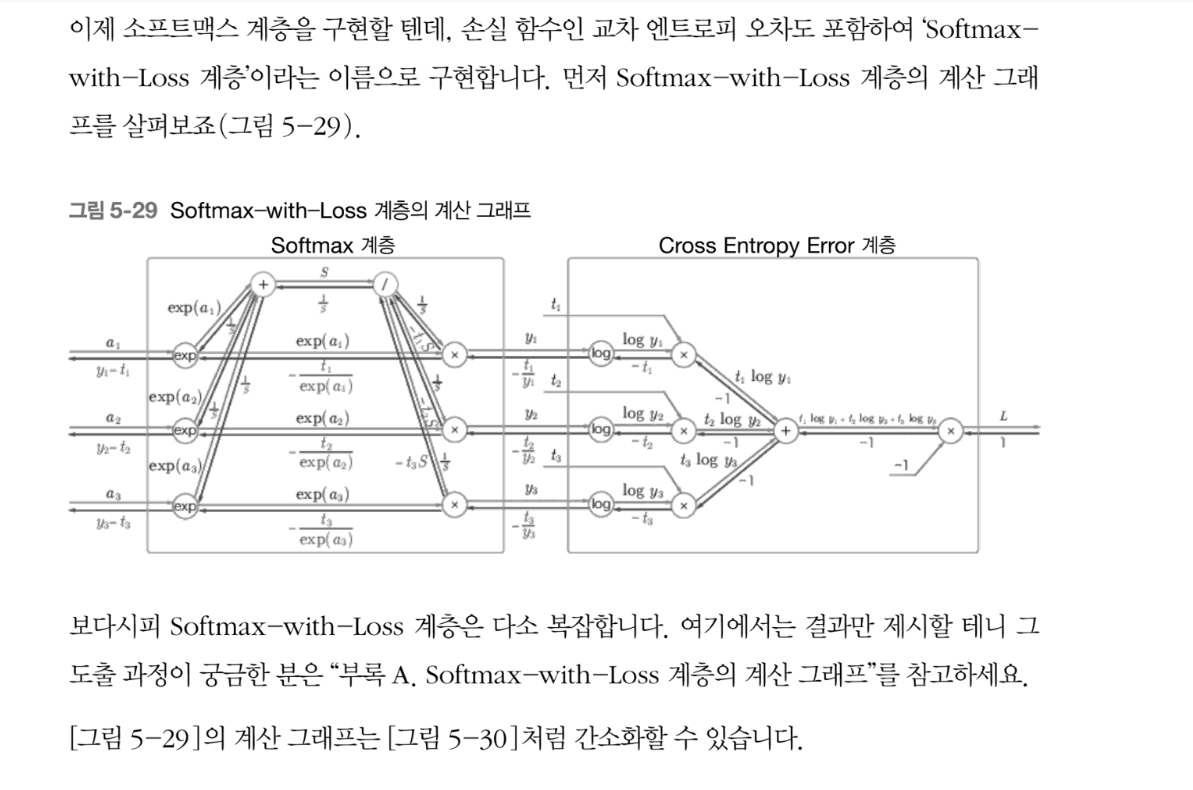
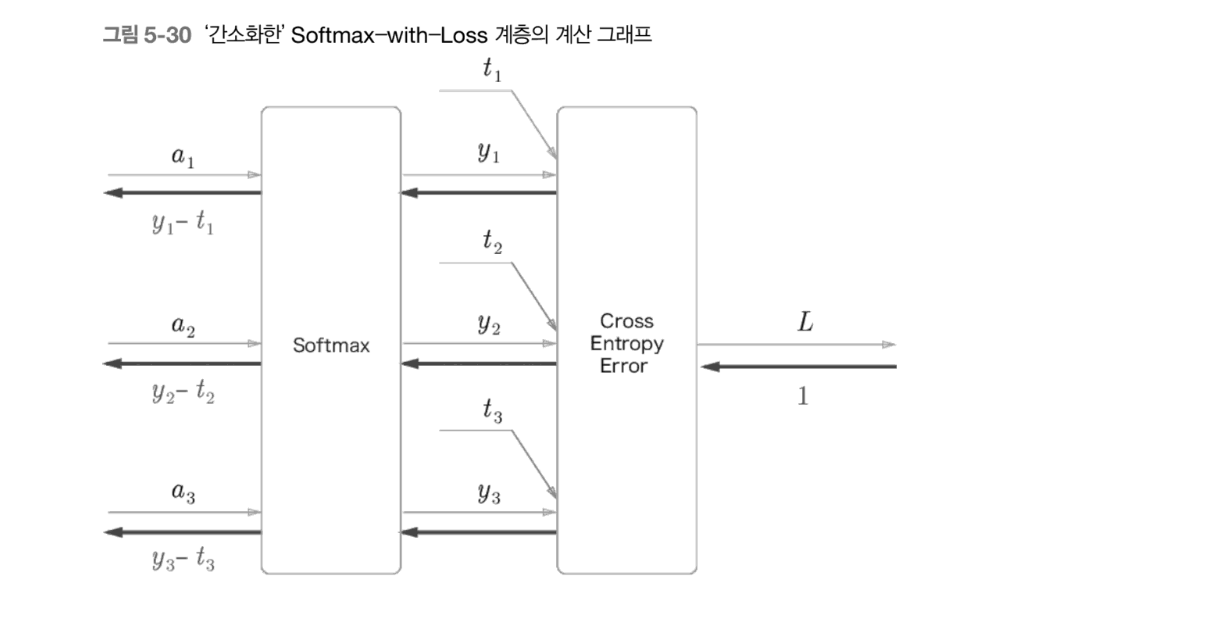